<a href="https://colab.research.google.com/github/xxashtonshen/computational-physics-fall-2026/blob/main/free-fall-meets-air-res/Free_Fall_Meets_Air_Resistance_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Free Fall Meets Air Resistance
Aidan Davies, Ashton Shen, Danny Cao

Import Files and Libraries

In [1]:
# Clone repository onto Google Colab session. Run only once per Colab runtime
!git clone https://github.com/xxashtonshen/computational-physics-fall-2026.git

fatal: destination path 'computational-physics-fall-2026' already exists and is not an empty directory.


In [2]:
# Pull the most recent version of the repository
%cd /content/computational-physics-fall-2026
!git pull
%cd ../

/content/computational-physics-fall-2026
Already up to date.
/content


In [3]:
# Import Libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Gathering Our Data

In [4]:
# Read in our data
df_beach = pd.DataFrame(pd.read_csv("computational-physics-fall-2026/free-fall-meets-air-res/data/BeachBall.csv"))
df_pool = pd.DataFrame(pd.read_csv("computational-physics-fall-2026/free-fall-meets-air-res/data/PoolBall.csv"))
df_golf = pd.DataFrame(pd.read_csv("computational-physics-fall-2026/free-fall-meets-air-res/data/GolfBall.csv"))
df_tiny = pd.DataFrame(pd.read_csv("computational-physics-fall-2026/free-fall-meets-air-res/data/TinyBall.csv"))

# Take a peak at one of them
df_beach.head()


,t,x1,x2,x3,x4
0,0.000,3.000,3.000,3.000,3.000
1,0.033,2.976,2.976,2.984,2.976
2,0.067,2.953,2.948,2.949,2.952
3,0.100,2.910,2.909,2.900,2.917
4,0.133,2.867,2.861,2.857,2.881


Build and Test the Integrator

In [5]:
# Establish gravity
G = 9.81

In [6]:
# Create the analytical free-fall solution w/o drag
def freeFall(y0):
  # Set the number of data points we want on our graph, the higher the number the smoother the curve
  t = np.linspace(0, np.sqrt(2*y0/G), 100)
  # Use the formula d = v0t + 0.5at^2
  y = y0 - 0.5*G*t**2

  return t, y

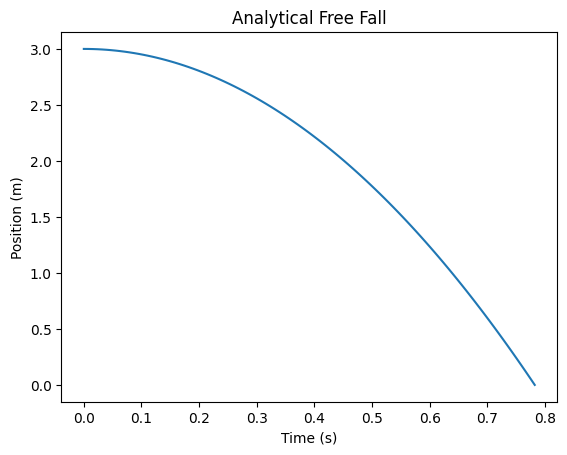

In [7]:
# Plot the analytical free-fall solution w/o drag
freeFall_t, freeFall_y = freeFall(3)
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.title("Analytical Free Fall")
plt.plot(freeFall_t, freeFall_y, label="Analytical")

plt.show()

In [8]:
# Create the Euler method function for just free-fall w/o drag
def euler_freeFall(y0, dt):
  t = 0
  v = 0
  y = y0

  times = [t]
  positions = [y]
  velocities = [v]

  while y > 0:
    y = y + v * dt
    v = v - G * dt
    t = t + dt

    # ensure the ball doesn't "phase" through the floor
    if y < 0:
      y = 0

    times.append(t)
    positions.append(y)
    velocities.append(v)

  return times, positions

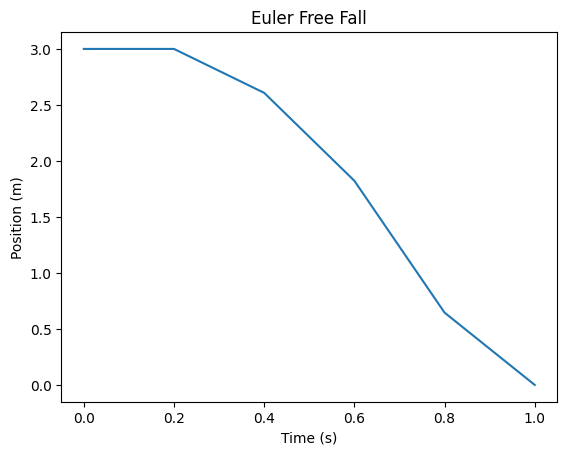

In [9]:
# Plot the Euler method with a large step size
euler_freeFall_t, euler_freeFall_y = euler_freeFall(3, 0.2)

plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.title("Euler Free Fall")
plt.plot(euler_freeFall_t, euler_freeFall_y, label="Euler")

plt.show()

Average linear difference: 0.30382515888352185



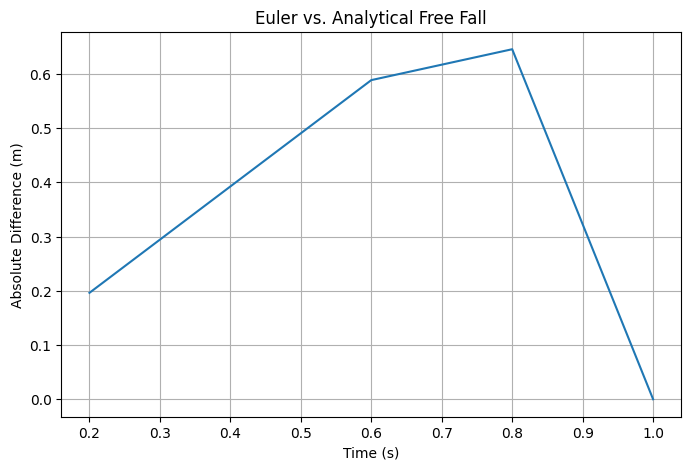


Absolute difference on loglog axis



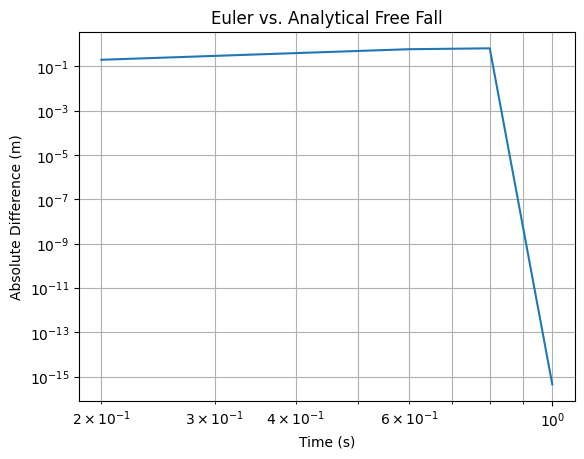

In [10]:
# Plotting the difference

# Interpolate the analytical solution at Euler's time points (in case the Euler has a data point the analytical solution doesn't)
freeFall_y_interp = np.interp(euler_freeFall_t, freeFall_t, freeFall_y)

diffs = np.abs(euler_freeFall_y - freeFall_y_interp)
avg_diff = np.mean(diffs)

plt.figure(figsize=(8, 5))

plt.plot(euler_freeFall_t[1:], diffs[1:])


# Plotting the difference linearly
plt.xlabel("Time (s)")
plt.ylabel("Absolute Difference (m)")
plt.title("Euler vs. Analytical Free Fall")
plt.grid(True, which="both")

print("Average linear difference: {}\n".format(avg_diff))
plt.show()

# Plotting the difference on loglog axis
plt.loglog(euler_freeFall_t[1:], diffs[1:])
plt.xlabel("Time (s)")
plt.ylabel("Absolute Difference (m)")
plt.title("Euler vs. Analytical Free Fall")
plt.grid(True, which="both")

print("\nAbsolute difference on loglog axis\n")
plt.show()

In [11]:
# As shown above, the absolute difference between Euler and analytical can be extremely large (~0.65 m) given large step sizes.
# To find a better step size while avoiding diminishing returns, we can use the measurement uncertainty from one of our set of trials, say from the beach ball.

In [12]:
# Create a function that calculates uncertainty,
# both as a function of time and the average uncertainty across each time for each of the ball's trials

def trial_stats(df, time_col="time", position_cols=None):
  # find the position columns if none are specified
  if position_cols is None:
      position_cols = [c for c in df.columns if c != time_col]

  # keep only times where every trial has a value
  trials = df.set_index(time_col)[position_cols].dropna(how="any")

  stats = pd.DataFrame({
      "mean": trials.mean(axis=1),
      "std": trials.std(axis=1, ddof=1),
  }).reset_index()

  return stats, stats["std"].mean()

Average std across time: 0.0264



<Axes: title={'center': 'Time (s) vs. STD'}, xlabel='t'>

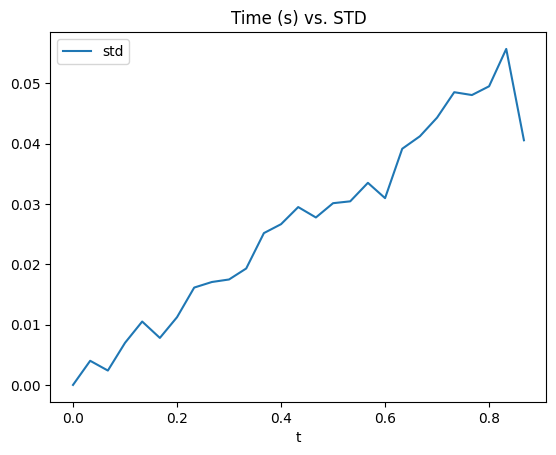

In [13]:
# Demonstrate how our average uncertainty looks for the beach ball

time_col = "t"
unc_beach, avg_std_beach = trial_stats(df_beach, time_col=time_col)
print(f"Average std across time: {avg_std_beach:.4f}\n")
unc_beach.plot(x=time_col, y="std", title="Time (s) vs. STD")

In [14]:
# Using decrementing step sizes for Euler, compare the average absolute difference from Euler with analytical to the average uncertainty of the beach ball
# Keep decrementing until the average absolute difference is lower than the average uncertainty

curr_step = 0.2
while avg_std_beach <= avg_diff:
  curr_step /= 2
  euler_freeFall_t, euler_freeFall_y = euler_freeFall(3, curr_step)

  # Repeat steps from earlier to find average absolute difference
  freeFall_y_interp = np.interp(euler_freeFall_t, freeFall_t, freeFall_y)
  diffs = np.abs(euler_freeFall_y - freeFall_y_interp)
  avg_diff = np.mean(diffs)

print(curr_step)

0.0125


In [15]:
# We should end up with an ideal step size of 0.0125, one that is accurate enough but not producing diminishing returns
best_step = curr_step

Data Analysis

In [16]:
# Set up constants for data analysis

dt = best_step
y0 = 3

In [17]:
# Create a simple function that calculates the acceleration at a point in time with air resistance

def get_acc(y, v, m, drag_type, coeff=None):
  if drag_type == 'linear':
    Fd = coeff * v
  elif drag_type == 'quadratic':
    Fd = coeff * (v ** 2)
  else:
    Fd = 0.0

  return (G - Fd / m)

In [18]:
# Create Euler method function for air resistance

def euler(y0, dt, m, drag_type, v0=0, t0=0, coeff=None):
  t, y, v = [t0], [y0], [v0]

  # keep taking Euler steps until the object reaches y = 0
  while y[-1] > 0:
    a = get_acc(y[-1], v[-1], m, drag_type, coeff)

    # Euler update
    v_new = v[-1] + a * dt
    y_new = y[-1] - v[-1] * dt
    t_new = t[-1] + dt

    v.append(v_new)
    y.append(y_new)
    t.append(t_new)

  return t, y

In [19]:
# Create Runge-Kutta method function for air resistance
# Implements both RK2 and RK4

# gets the next velocity and acceleration
def derivs(y, v, m, drag_type, coeff):
  """dy/dt and dv/dt. y' = -v because v is the downward speed."""
  return -v, get_acc(y, v, m, drag_type, coeff)

def rk2_step(y, v, dt, f):
  k1_y, k1_v = f(y, v)
  k2_y, k2_v = f(y + 0.5*dt*k1_y, v + 0.5*dt*k1_v)
  return y + dt*k2_y, v + dt*k2_v

def rk4_step(y, v, dt, f):
  k1_y, k1_v = f(y, v)
  k2_y, k2_v = f(y + 0.5*dt*k1_y, v + 0.5*dt*k1_v)
  k3_y, k3_v = f(y + 0.5*dt*k2_y, v + 0.5*dt*k2_v)
  k4_y, k4_v = f(y + dt*k3_y,     v + dt*k3_v)
  y_new = y + (dt/6) * (k1_y + 2*k2_y + 2*k3_y + k4_y)
  v_new = v + (dt/6) * (k1_v + 2*k2_v + 2*k3_v + k4_v)
  return y_new, v_new

STEPPERS = {"rk2": rk2_step, "rk4": rk4_step}

def rk_fall(y0, dt, m, drag_type, coeff, method, v0=0, t0=0):
  step = STEPPERS[method]
  f = lambda y, v: derivs(y, v, m, drag_type, coeff)

  t, y, v = [t0], [y0], [v0]

  while y[-1] > 0:
    y_new, v_new = step(y[-1], v[-1], dt, f)

    t.append(t[-1] + dt)
    y.append(y_new)
    v.append(v_new)

  return np.array(t), np.array(y)

Beach Ball Data Compared to Free Fall Graph (Euler)

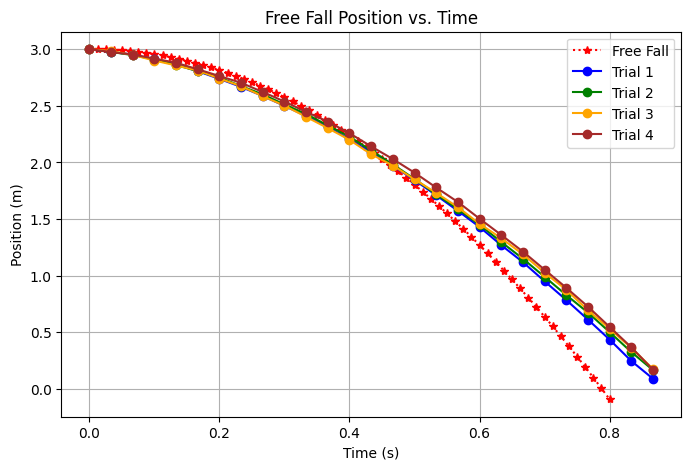

In [20]:
# extract times and positions using column indexing
time1, pos1 = df_beach['t'], df_beach['x1']
time2, pos2 = df_beach['t'], df_beach['x2']
time3, pos3 = df_beach['t'], df_beach['x3']
time4, pos4 = df_beach['t'], df_beach['x4']

# establish parameters
m = 0.0375
b = 3.92e-5
c = 0.0127

euler_freeFall_t, euler_freeFall_y = euler(3, dt, m, drag_type=None)

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(euler_freeFall_t, euler_freeFall_y, label = 'Free Fall', marker = '*', ls = ':', color = 'red')
# drop 1
plt.plot(time1, pos1, label = 'Trial 1', marker = 'o', ls = '-', color = 'blue')
# drop 2
plt.plot(time2, pos2, label = 'Trial 2', marker = 'o', ls = '-', color = 'green')
# drop 3
plt.plot(time3, pos3, label = 'Trial 3', marker = 'o', ls = '-', color = 'orange')
# drop 4
plt.plot(time4, pos4, label = 'Trial 4', marker = 'o', ls = '-', color = 'brown')

# Format the plot
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Free Fall Position vs. Time')
plt.legend()
plt.grid(True)
plt.show()

Beach Ball Data Compared to Euler Method Graph

RMSE for linear model Trial 1: 0.1985
RMSE for quadratic model Trial 1: 0.1046
RMSE for linear model Trial 2: 0.2263
RMSE for quadratic model Trial 2: 0.0765
RMSE for linear model Trial 3: 0.2439
RMSE for quadratic model Trial 3: 0.0728
RMSE for linear model Trial 4: 0.2557
RMSE for quadratic model Trial 4: 0.0439


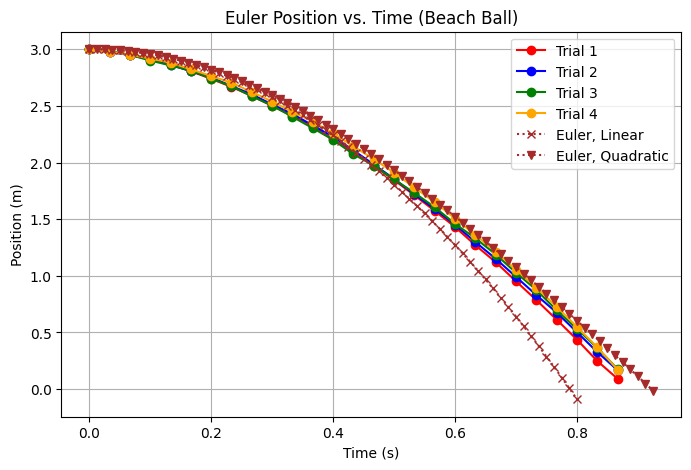

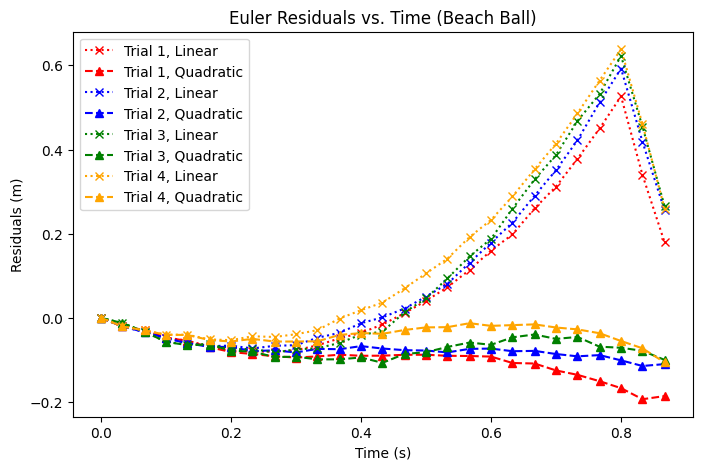

In [21]:
# Euler estimation of linear drag
euler_linear_t, euler_linear_y = euler(3, dt, m, "linear", coeff=b)

# Euler estimation of quadratic drag
euler_quadratic_t, euler_quadratic_y = euler(3, dt, m, "quadratic", coeff=c)

# determine the better match
# use interpolate to get consistent data throughout
euler_linear_y_interp = np.interp(time1, euler_linear_t, euler_linear_y)
euler_quadratic_y_interp = np.interp(time1, euler_quadratic_t, euler_quadratic_y)

# find the residuals
euler_y1l_residuals, euler_y1q_residuals = pos1 - euler_linear_y_interp, pos1 - euler_quadratic_y_interp
euler_y2l_residuals, euler_y2q_residuals = pos2 - euler_linear_y_interp, pos2 - euler_quadratic_y_interp
euler_y3l_residuals, euler_y3q_residuals = pos3 - euler_linear_y_interp, pos3 - euler_quadratic_y_interp
euler_y4l_residuals, euler_y4q_residuals = pos4 - euler_linear_y_interp, pos4 - euler_quadratic_y_interp
# find the root mean square error
euler_rmse_linear1 = np.sqrt(np.mean((euler_y1l_residuals) ** 2))
euler_rmse_quadratic1 = np.sqrt(np.mean((euler_y1q_residuals) ** 2))
euler_rmse_linear2 = np.sqrt(np.mean((euler_y2l_residuals) ** 2))
euler_rmse_quadratic2 = np.sqrt(np.mean((euler_y2q_residuals) ** 2))
euler_rmse_linear3 = np.sqrt(np.mean((euler_y3l_residuals) ** 2))
euler_rmse_quadratic3 = np.sqrt(np.mean((euler_y3q_residuals) ** 2))
euler_rmse_linear4 = np.sqrt(np.mean((euler_y4l_residuals) ** 2))
euler_rmse_quadratic4 = np.sqrt(np.mean((euler_y4q_residuals) ** 2))

print(f"RMSE for linear model Trial 1: {euler_rmse_linear1:.4f}")
print(f"RMSE for quadratic model Trial 1: {euler_rmse_quadratic1:.4f}")
print(f"RMSE for linear model Trial 2: {euler_rmse_linear2:.4f}")
print(f"RMSE for quadratic model Trial 2: {euler_rmse_quadratic2:.4f}")
print(f"RMSE for linear model Trial 3: {euler_rmse_linear3:.4f}")
print(f"RMSE for quadratic model Trial 3: {euler_rmse_quadratic3:.4f}")
print(f"RMSE for linear model Trial 4: {euler_rmse_linear4:.4f}")
print(f"RMSE for quadratic model Trial 4: {euler_rmse_quadratic4:.4f}")

# Create the plot
plt.figure(figsize=(8, 5))
# drop 1
plt.plot(time1, pos1, label = 'Trial 1', marker = 'o', ls = '-', color = 'red')
# drop 2
plt.plot(time2, pos2, label = 'Trial 2', marker = 'o', ls = '-', color = 'blue')
# drop 3
plt.plot(time3, pos3, label = 'Trial 3', marker = 'o', ls = '-', color = 'green')
# drop 4
plt.plot(time4, pos4, label = 'Trial 4', marker = 'o', ls = '-', color = 'orange')

plt.plot(euler_linear_t, euler_linear_y, label = f'Euler, Linear', marker = 'x', ls = ':', color = 'brown')
plt.plot(euler_quadratic_t, euler_quadratic_y, label = f'Euler, Quadratic', marker = 'v', ls = ':', color = 'brown')

# Format the plot
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Euler Position vs. Time (Beach Ball)')
plt.legend()
plt.grid(True)
plt.show()

# plot residuals with time
plt.figure(figsize=(8, 5))
plt.plot(time1, euler_y1l_residuals, label = 'Trial 1, Linear', marker = 'x', ls = ':', color = 'red')
plt.plot(time1, euler_y1q_residuals, label = 'Trial 1, Quadratic', marker = '^', ls = '--', color = 'red')
plt.plot(time2, euler_y2l_residuals, label = 'Trial 2, Linear', marker = 'x', ls = ':', color = 'blue')
plt.plot(time2, euler_y2q_residuals, label = 'Trial 2, Quadratic', marker = '^', ls = '--', color = 'blue')
plt.plot(time3, euler_y3l_residuals, label = 'Trial 3, Linear', marker = 'x', ls = ':', color = 'green')
plt.plot(time3, euler_y3q_residuals, label = 'Trial 3, Quadratic', marker = '^', ls = '--', color = 'green')
plt.plot(time3, euler_y4l_residuals, label = 'Trial 4, Linear', marker = 'x', ls = ':', color = 'orange')
plt.plot(time3, euler_y4q_residuals, label = 'Trial 4, Quadratic', marker = '^', ls = '--', color = 'orange')
plt.xlabel('Time (s)')
plt.ylabel('Residuals (m)')
plt.title('Euler Residuals vs. Time (Beach Ball)')
plt.legend()

Data Compared to RK2 Graph

RMSE for linear model Trial 1: 0.2050
RMSE for quadratic model Trial 1: 0.0891
RMSE for linear model Trial 2: 0.2324
RMSE for quadratic model Trial 2: 0.0607
RMSE for linear model Trial 3: 0.2499
RMSE for quadratic model Trial 3: 0.0578
RMSE for linear model Trial 4: 0.2643
RMSE for quadratic model Trial 4: 0.0317


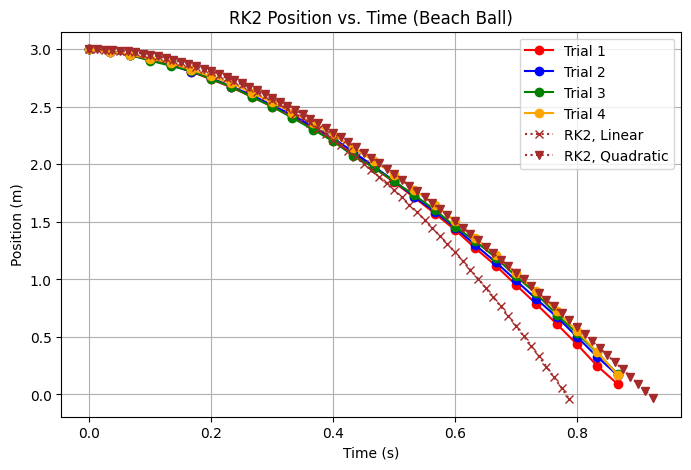

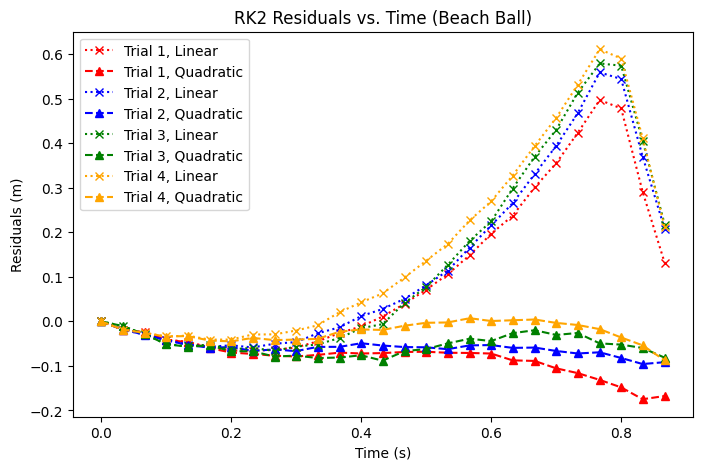

In [22]:
# RK2 estimation of linear drag
rk2_linear_t, rk2_linear_y = rk_fall(3, dt, m, "linear", b, "rk2")

# RK2 estimation of quadratic drag
rk2_quadratic_t, rk2_quadratic_y = rk_fall(3, dt, m, "quadratic", c, "rk2")

# determine the better match
# use interpolate to get consistent data throughout
rk2_linear_y_interp = np.interp(time1, rk2_linear_t, rk2_linear_y)
rk2_quadratic_y_interp = np.interp(time1, rk2_quadratic_t, rk2_quadratic_y)

# find the residuals
rk2_y1l_residuals, rk2_y1q_residuals = pos1 - rk2_linear_y_interp, pos1 - rk2_quadratic_y_interp
rk2_y2l_residuals, rk2_y2q_residuals = pos2 - rk2_linear_y_interp, pos2 - rk2_quadratic_y_interp
rk2_y3l_residuals, rk2_y3q_residuals = pos3 - rk2_linear_y_interp, pos3 - rk2_quadratic_y_interp
rk2_y4l_residuals, rk2_y4q_residuals = pos4 - rk2_linear_y_interp, pos4 - rk2_quadratic_y_interp
# find the root mean square error
rk2_rmse_linear1 = np.sqrt(np.mean((rk2_y1l_residuals) ** 2))
rk2_rmse_quadratic1 = np.sqrt(np.mean((rk2_y1q_residuals) ** 2))
rk2_rmse_linear2 = np.sqrt(np.mean((rk2_y2l_residuals) ** 2))
rk2_rmse_quadratic2 = np.sqrt(np.mean((rk2_y2q_residuals) ** 2))
rk2_rmse_linear3 = np.sqrt(np.mean((rk2_y3l_residuals) ** 2))
rk2_rmse_quadratic3 = np.sqrt(np.mean((rk2_y3q_residuals) ** 2))
rk2_rmse_linear4 = np.sqrt(np.mean((rk2_y4l_residuals) ** 2))
rk2_rmse_quadratic4 = np.sqrt(np.mean((rk2_y4q_residuals) ** 2))

print(f"RMSE for linear model Trial 1: {rk2_rmse_linear1:.4f}")
print(f"RMSE for quadratic model Trial 1: {rk2_rmse_quadratic1:.4f}")
print(f"RMSE for linear model Trial 2: {rk2_rmse_linear2:.4f}")
print(f"RMSE for quadratic model Trial 2: {rk2_rmse_quadratic2:.4f}")
print(f"RMSE for linear model Trial 3: {rk2_rmse_linear3:.4f}")
print(f"RMSE for quadratic model Trial 3: {rk2_rmse_quadratic3:.4f}")
print(f"RMSE for linear model Trial 4: {rk2_rmse_linear4:.4f}")
print(f"RMSE for quadratic model Trial 4: {rk2_rmse_quadratic4:.4f}")

# Create the plot
plt.figure(figsize=(8, 5))
# drop 1
plt.plot(time1, pos1, label = 'Trial 1', marker = 'o', ls = '-', color = 'red')
# drop 2
plt.plot(time2, pos2, label = 'Trial 2', marker = 'o', ls = '-', color = 'blue')
# drop 3
plt.plot(time3, pos3, label = 'Trial 3', marker = 'o', ls = '-', color = 'green')
# drop 4
plt.plot(time4, pos4, label = 'Trial 4', marker = 'o', ls = '-', color = 'orange')

plt.plot(rk2_linear_t, rk2_linear_y, label = f'RK2, Linear', marker = 'x', ls = ':', color = 'brown')
plt.plot(rk2_quadratic_t, rk2_quadratic_y, label = f'RK2, Quadratic', marker = 'v', ls = ':', color = 'brown')

# Format the plot
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('RK2 Position vs. Time (Beach Ball)')
plt.legend()
plt.grid(True)
plt.show()

# plot residuals with time
plt.figure(figsize=(8, 5))
plt.plot(time1, rk2_y1l_residuals, label = 'Trial 1, Linear', marker = 'x', ls = ':', color = 'red')
plt.plot(time1, rk2_y1q_residuals, label = 'Trial 1, Quadratic', marker = '^', ls = '--', color = 'red')
plt.plot(time2, rk2_y2l_residuals, label = 'Trial 2, Linear', marker = 'x', ls = ':', color = 'blue')
plt.plot(time2, rk2_y2q_residuals, label = 'Trial 2, Quadratic', marker = '^', ls = '--', color = 'blue')
plt.plot(time3, rk2_y3l_residuals, label = 'Trial 3, Linear', marker = 'x', ls = ':', color = 'green')
plt.plot(time3, rk2_y3q_residuals, label = 'Trial 3, Quadratic', marker = '^', ls = '--', color = 'green')
plt.plot(time4, rk2_y4l_residuals, label = 'Trial 4, Linear', marker = 'x', ls = ':', color = 'orange')
plt.plot(time4, rk2_y4q_residuals, label = 'Trial 4, Quadratic', marker = '^', ls = '--', color = 'orange')
plt.xlabel('Time (s)')
plt.ylabel('Residuals (m)')
plt.title('RK2 Residuals vs. Time (Beach Ball)')
plt.legend()

Data Compared to RK4 Graph

RMSE for linear model Trial 1: 0.2050
RMSE for quadratic model Trial 1: 0.0892
RMSE for linear model Trial 2: 0.2324
RMSE for quadratic model Trial 2: 0.0608
RMSE for linear model Trial 3: 0.2499
RMSE for quadratic model Trial 3: 0.0579
RMSE for linear model Trial 4: 0.2643
RMSE for quadratic model Trial 4: 0.0318


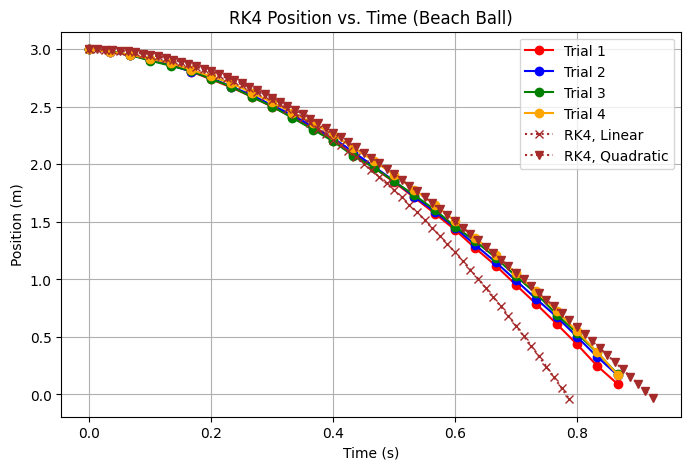

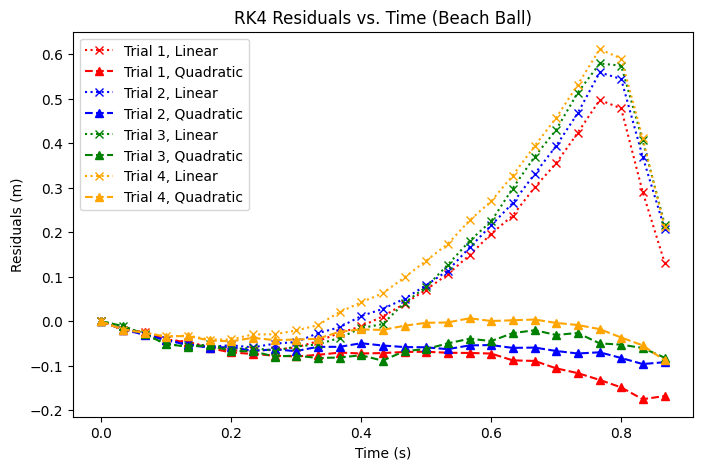

In [23]:
# RK4 estimation of linear drag
rk4_linear_t, rk4_linear_y = rk_fall(3, dt, m, "linear", b, "rk4")

# RK4 estimation of quadratic drag
rk4_quadratic_t, rk4_quadratic_y = rk_fall(3, dt, m, "quadratic", c, "rk4")

# determine the better match
# use interpolate to get consistent data throughout
rk4_linear_y_interp = np.interp(time1, rk4_linear_t, rk4_linear_y)
rk4_quadratic_y_interp = np.interp(time1, rk4_quadratic_t, rk4_quadratic_y)

# find the residuals
rk4_y1l_residuals, rk4_y1q_residuals = pos1 - rk4_linear_y_interp, pos1 - rk4_quadratic_y_interp
rk4_y2l_residuals, rk4_y2q_residuals = pos2 - rk4_linear_y_interp, pos2 - rk4_quadratic_y_interp
rk4_y3l_residuals, rk4_y3q_residuals = pos3 - rk4_linear_y_interp, pos3 - rk4_quadratic_y_interp
rk4_y4l_residuals, rk4_y4q_residuals = pos4 - rk4_linear_y_interp, pos4 - rk4_quadratic_y_interp
# find the root mean square error
rk4_rmse_linear1 = np.sqrt(np.mean((rk4_y1l_residuals) ** 2))
rk4_rmse_quadratic1 = np.sqrt(np.mean((rk4_y1q_residuals) ** 2))
rk4_rmse_linear2 = np.sqrt(np.mean((rk4_y2l_residuals) ** 2))
rk4_rmse_quadratic2 = np.sqrt(np.mean((rk4_y2q_residuals) ** 2))
rk4_rmse_linear3 = np.sqrt(np.mean((rk4_y3l_residuals) ** 2))
rk4_rmse_quadratic3 = np.sqrt(np.mean((rk4_y3q_residuals) ** 2))
rk4_rmse_linear4 = np.sqrt(np.mean((rk4_y4l_residuals) ** 2))
rk4_rmse_quadratic4 = np.sqrt(np.mean((rk4_y4q_residuals) ** 2))

print(f"RMSE for linear model Trial 1: {rk4_rmse_linear1:.4f}")
print(f"RMSE for quadratic model Trial 1: {rk4_rmse_quadratic1:.4f}")
print(f"RMSE for linear model Trial 2: {rk4_rmse_linear2:.4f}")
print(f"RMSE for quadratic model Trial 2: {rk4_rmse_quadratic2:.4f}")
print(f"RMSE for linear model Trial 3: {rk4_rmse_linear3:.4f}")
print(f"RMSE for quadratic model Trial 3: {rk4_rmse_quadratic3:.4f}")
print(f"RMSE for linear model Trial 4: {rk4_rmse_linear4:.4f}")
print(f"RMSE for quadratic model Trial 4: {rk4_rmse_quadratic4:.4f}")

# Create the plot
plt.figure(figsize=(8, 5))
# drop 1
plt.plot(time1, pos1, label = 'Trial 1', marker = 'o', ls = '-', color = 'red')
# drop 2
plt.plot(time2, pos2, label = 'Trial 2', marker = 'o', ls = '-', color = 'blue')
# drop 3
plt.plot(time3, pos3, label = 'Trial 3', marker = 'o', ls = '-', color = 'green')
# drop 4
plt.plot(time4, pos4, label = 'Trial 4', marker = 'o', ls = '-', color = 'orange')

plt.plot(rk4_linear_t, rk4_linear_y, label = f'RK4, Linear', marker = 'x', ls = ':', color = 'brown')
plt.plot(rk4_quadratic_t, rk4_quadratic_y, label = f'RK4, Quadratic', marker = 'v', ls = ':', color = 'brown')

# Format the plot
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('RK4 Position vs. Time (Beach Ball)')
plt.legend()
plt.grid(True)
plt.show()

# plot residuals with time
plt.figure(figsize=(8, 5))
plt.plot(time1, rk4_y1l_residuals, label = 'Trial 1, Linear', marker = 'x', ls = ':', color = 'red')
plt.plot(time1, rk4_y1q_residuals, label = 'Trial 1, Quadratic', marker = '^', ls = '--', color = 'red')
plt.plot(time2, rk4_y2l_residuals, label = 'Trial 2, Linear', marker = 'x', ls = ':', color = 'blue')
plt.plot(time2, rk4_y2q_residuals, label = 'Trial 2, Quadratic', marker = '^', ls = '--', color = 'blue')
plt.plot(time3, rk4_y3l_residuals, label = 'Trial 3, Linear', marker = 'x', ls = ':', color = 'green')
plt.plot(time3, rk4_y3q_residuals, label = 'Trial 3, Quadratic', marker = '^', ls = '--', color = 'green')
plt.plot(time4, rk4_y4l_residuals, label = 'Trial 4, Linear', marker = 'x', ls = ':', color = 'orange')
plt.plot(time4, rk4_y4q_residuals, label = 'Trial 4, Quadratic', marker = '^', ls = '--', color = 'orange')
plt.xlabel('Time (s)')
plt.ylabel('Residuals (m)')
plt.title('RK4 Residuals vs. Time (Beach Ball)')
plt.legend()

Pool Ball Data


In [24]:
# extract times and positions using column indexing
time1, pos1 = df_pool['t'], df_pool['x1']
time2, pos2 = df_pool['t'], df_pool['x2']
time3, pos3 = df_pool['t'], df_pool['x3']
time4, pos4 = df_pool['t'], df_pool['x4']

# establish parameters for beach ball
m = 0.1888
b = 8.66e-4
c = 1.02e-5

RMSE for linear model Trial 1: 0.0932
RMSE for quadratic model Trial 1: 0.0922
RMSE for linear model Trial 2: 0.1564
RMSE for quadratic model Trial 2: 0.1554
RMSE for linear model Trial 3: 0.1593
RMSE for quadratic model Trial 3: 0.1583
RMSE for linear model Trial 4: 0.0999
RMSE for quadratic model Trial 4: 0.0989


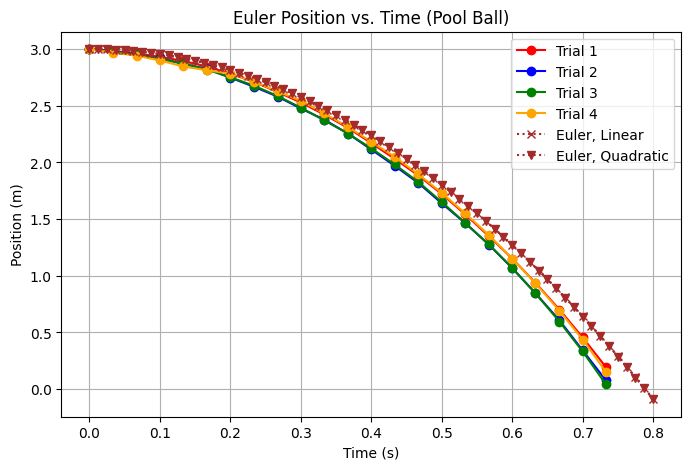

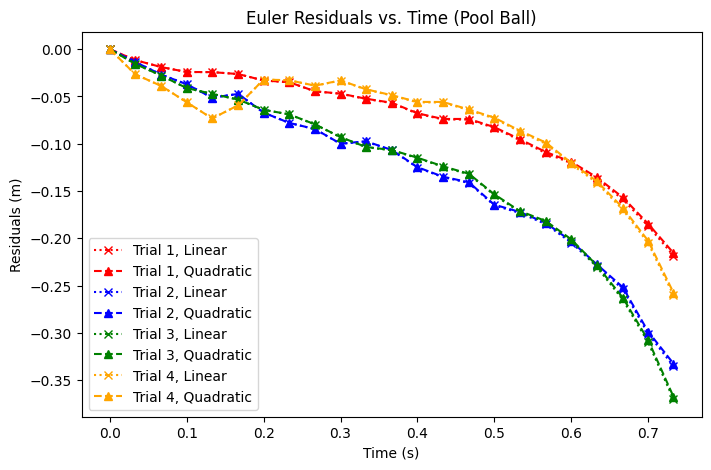

In [25]:
# Euler estimation of linear drag
euler_linear_t, euler_linear_y = euler(3, dt, m, "linear", coeff=b)

# Euler estimation of quadratic drag
euler_quadratic_t, euler_quadratic_y = euler(3, dt, m, "quadratic", coeff=c)

# determine the better match
# use interpolate to get consistent data throughout
euler_linear_y_interp = np.interp(time1, euler_linear_t, euler_linear_y)
euler_quadratic_y_interp = np.interp(time1, euler_quadratic_t, euler_quadratic_y)

# find the residuals
euler_y1l_residuals, euler_y1q_residuals = pos1 - euler_linear_y_interp, pos1 - euler_quadratic_y_interp
euler_y2l_residuals, euler_y2q_residuals = pos2 - euler_linear_y_interp, pos2 - euler_quadratic_y_interp
euler_y3l_residuals, euler_y3q_residuals = pos3 - euler_linear_y_interp, pos3 - euler_quadratic_y_interp
euler_y4l_residuals, euler_y4q_residuals = pos4 - euler_linear_y_interp, pos4 - euler_quadratic_y_interp
# find the root mean square error
euler_rmse_linear1 = np.sqrt(np.mean((euler_y1l_residuals) ** 2))
euler_rmse_quadratic1 = np.sqrt(np.mean((euler_y1q_residuals) ** 2))
euler_rmse_linear2 = np.sqrt(np.mean((euler_y2l_residuals) ** 2))
euler_rmse_quadratic2 = np.sqrt(np.mean((euler_y2q_residuals) ** 2))
euler_rmse_linear3 = np.sqrt(np.mean((euler_y3l_residuals) ** 2))
euler_rmse_quadratic3 = np.sqrt(np.mean((euler_y3q_residuals) ** 2))
euler_rmse_linear4 = np.sqrt(np.mean((euler_y4l_residuals) ** 2))
euler_rmse_quadratic4 = np.sqrt(np.mean((euler_y4q_residuals) ** 2))

print(f"RMSE for linear model Trial 1: {euler_rmse_linear1:.4f}")
print(f"RMSE for quadratic model Trial 1: {euler_rmse_quadratic1:.4f}")
print(f"RMSE for linear model Trial 2: {euler_rmse_linear2:.4f}")
print(f"RMSE for quadratic model Trial 2: {euler_rmse_quadratic2:.4f}")
print(f"RMSE for linear model Trial 3: {euler_rmse_linear3:.4f}")
print(f"RMSE for quadratic model Trial 3: {euler_rmse_quadratic3:.4f}")
print(f"RMSE for linear model Trial 4: {euler_rmse_linear4:.4f}")
print(f"RMSE for quadratic model Trial 4: {euler_rmse_quadratic4:.4f}")

# Create the plot
plt.figure(figsize=(8, 5))
# drop 1
plt.plot(time1, pos1, label = 'Trial 1', marker = 'o', ls = '-', color = 'red')
# drop 2
plt.plot(time2, pos2, label = 'Trial 2', marker = 'o', ls = '-', color = 'blue')
# drop 3
plt.plot(time3, pos3, label = 'Trial 3', marker = 'o', ls = '-', color = 'green')
# drop 4
plt.plot(time4, pos4, label = 'Trial 4', marker = 'o', ls = '-', color = 'orange')

plt.plot(euler_linear_t, euler_linear_y, label = f'Euler, Linear', marker = 'x', ls = ':', color = 'brown')
plt.plot(euler_quadratic_t, euler_quadratic_y, label = f'Euler, Quadratic', marker = 'v', ls = ':', color = 'brown')

# Format the plot
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Euler Position vs. Time (Pool Ball)')
plt.legend()
plt.grid(True)
plt.show()

# plot residuals with time
plt.figure(figsize=(8, 5))
plt.plot(time1, euler_y1l_residuals, label = 'Trial 1, Linear', marker = 'x', ls = ':', color = 'red')
plt.plot(time1, euler_y1q_residuals, label = 'Trial 1, Quadratic', marker = '^', ls = '--', color = 'red')
plt.plot(time2, euler_y2l_residuals, label = 'Trial 2, Linear', marker = 'x', ls = ':', color = 'blue')
plt.plot(time2, euler_y2q_residuals, label = 'Trial 2, Quadratic', marker = '^', ls = '--', color = 'blue')
plt.plot(time3, euler_y3l_residuals, label = 'Trial 3, Linear', marker = 'x', ls = ':', color = 'green')
plt.plot(time3, euler_y3q_residuals, label = 'Trial 3, Quadratic', marker = '^', ls = '--', color = 'green')
plt.plot(time3, euler_y4l_residuals, label = 'Trial 4, Linear', marker = 'x', ls = ':', color = 'orange')
plt.plot(time3, euler_y4q_residuals, label = 'Trial 4, Quadratic', marker = '^', ls = '--', color = 'orange')
plt.xlabel('Time (s)')
plt.ylabel('Residuals (m)')
plt.title('Euler Residuals vs. Time (Pool Ball)')
plt.legend()

RMSE for linear model Trial 1: 0.0679
RMSE for quadratic model Trial 1: 0.0668
RMSE for linear model Trial 2: 0.1306
RMSE for quadratic model Trial 2: 0.1295
RMSE for linear model Trial 3: 0.1338
RMSE for quadratic model Trial 3: 0.1326
RMSE for linear model Trial 4: 0.0760
RMSE for quadratic model Trial 4: 0.0749


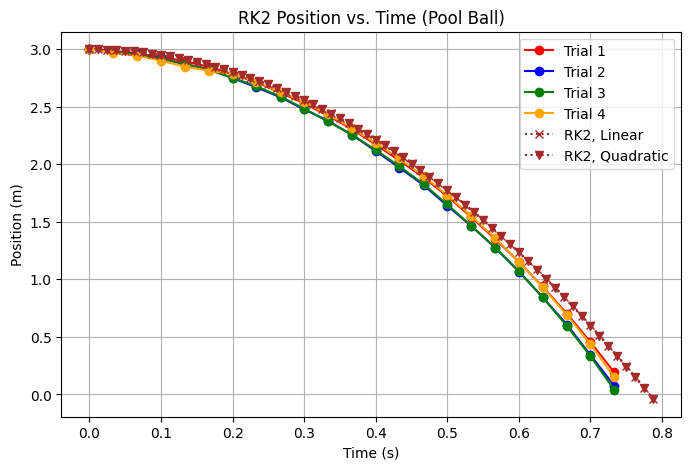

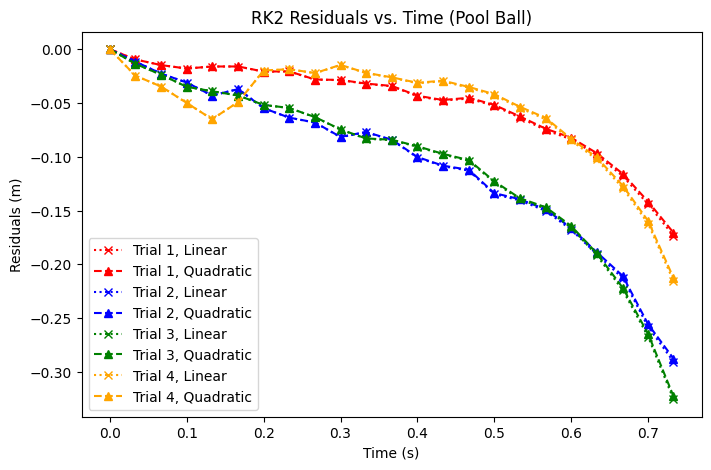

In [26]:
# RK2 estimation of linear drag
rk2_linear_t, rk2_linear_y = rk_fall(3, dt, m, "linear", b, "rk2")

# RK2 estimation of quadratic drag
rk2_quadratic_t, rk2_quadratic_y = rk_fall(3, dt, m, "quadratic", c, "rk2")

# determine the better match
# use interpolate to get consistent data throughout
rk2_linear_y_interp = np.interp(time1, rk2_linear_t, rk2_linear_y)
rk2_quadratic_y_interp = np.interp(time1, rk2_quadratic_t, rk2_quadratic_y)

# find the residuals
rk2_y1l_residuals, rk2_y1q_residuals = pos1 - rk2_linear_y_interp, pos1 - rk2_quadratic_y_interp
rk2_y2l_residuals, rk2_y2q_residuals = pos2 - rk2_linear_y_interp, pos2 - rk2_quadratic_y_interp
rk2_y3l_residuals, rk2_y3q_residuals = pos3 - rk2_linear_y_interp, pos3 - rk2_quadratic_y_interp
rk2_y4l_residuals, rk2_y4q_residuals = pos4 - rk2_linear_y_interp, pos4 - rk2_quadratic_y_interp
# find the root mean square error
rk2_rmse_linear1 = np.sqrt(np.mean((rk2_y1l_residuals) ** 2))
rk2_rmse_quadratic1 = np.sqrt(np.mean((rk2_y1q_residuals) ** 2))
rk2_rmse_linear2 = np.sqrt(np.mean((rk2_y2l_residuals) ** 2))
rk2_rmse_quadratic2 = np.sqrt(np.mean((rk2_y2q_residuals) ** 2))
rk2_rmse_linear3 = np.sqrt(np.mean((rk2_y3l_residuals) ** 2))
rk2_rmse_quadratic3 = np.sqrt(np.mean((rk2_y3q_residuals) ** 2))
rk2_rmse_linear4 = np.sqrt(np.mean((rk2_y4l_residuals) ** 2))
rk2_rmse_quadratic4 = np.sqrt(np.mean((rk2_y4q_residuals) ** 2))

print(f"RMSE for linear model Trial 1: {rk2_rmse_linear1:.4f}")
print(f"RMSE for quadratic model Trial 1: {rk2_rmse_quadratic1:.4f}")
print(f"RMSE for linear model Trial 2: {rk2_rmse_linear2:.4f}")
print(f"RMSE for quadratic model Trial 2: {rk2_rmse_quadratic2:.4f}")
print(f"RMSE for linear model Trial 3: {rk2_rmse_linear3:.4f}")
print(f"RMSE for quadratic model Trial 3: {rk2_rmse_quadratic3:.4f}")
print(f"RMSE for linear model Trial 4: {rk2_rmse_linear4:.4f}")
print(f"RMSE for quadratic model Trial 4: {rk2_rmse_quadratic4:.4f}")

# Create the plot
plt.figure(figsize=(8, 5))
# drop 1
plt.plot(time1, pos1, label = 'Trial 1', marker = 'o', ls = '-', color = 'red')
# drop 2
plt.plot(time2, pos2, label = 'Trial 2', marker = 'o', ls = '-', color = 'blue')
# drop 3
plt.plot(time3, pos3, label = 'Trial 3', marker = 'o', ls = '-', color = 'green')
# drop 4
plt.plot(time4, pos4, label = 'Trial 4', marker = 'o', ls = '-', color = 'orange')

plt.plot(rk2_linear_t, rk2_linear_y, label = f'RK2, Linear', marker = 'x', ls = ':', color = 'brown')
plt.plot(rk2_quadratic_t, rk2_quadratic_y, label = f'RK2, Quadratic', marker = 'v', ls = ':', color = 'brown')

# Format the plot
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('RK2 Position vs. Time (Pool Ball)')
plt.legend()
plt.grid(True)
plt.show()

# plot residuals with time
plt.figure(figsize=(8, 5))
plt.plot(time1, rk2_y1l_residuals, label = 'Trial 1, Linear', marker = 'x', ls = ':', color = 'red')
plt.plot(time1, rk2_y1q_residuals, label = 'Trial 1, Quadratic', marker = '^', ls = '--', color = 'red')
plt.plot(time2, rk2_y2l_residuals, label = 'Trial 2, Linear', marker = 'x', ls = ':', color = 'blue')
plt.plot(time2, rk2_y2q_residuals, label = 'Trial 2, Quadratic', marker = '^', ls = '--', color = 'blue')
plt.plot(time3, rk2_y3l_residuals, label = 'Trial 3, Linear', marker = 'x', ls = ':', color = 'green')
plt.plot(time3, rk2_y3q_residuals, label = 'Trial 3, Quadratic', marker = '^', ls = '--', color = 'green')
plt.plot(time4, rk2_y4l_residuals, label = 'Trial 4, Linear', marker = 'x', ls = ':', color = 'orange')
plt.plot(time4, rk2_y4q_residuals, label = 'Trial 4, Quadratic', marker = '^', ls = '--', color = 'orange')
plt.xlabel('Time (s)')
plt.ylabel('Residuals (m)')
plt.title('RK2 Residuals vs. Time (Pool Ball)')
plt.legend()

RMSE for linear model Trial 1: 0.0679
RMSE for quadratic model Trial 1: 0.0668
RMSE for linear model Trial 2: 0.1306
RMSE for quadratic model Trial 2: 0.1295
RMSE for linear model Trial 3: 0.1338
RMSE for quadratic model Trial 3: 0.1326
RMSE for linear model Trial 4: 0.0760
RMSE for quadratic model Trial 4: 0.0749


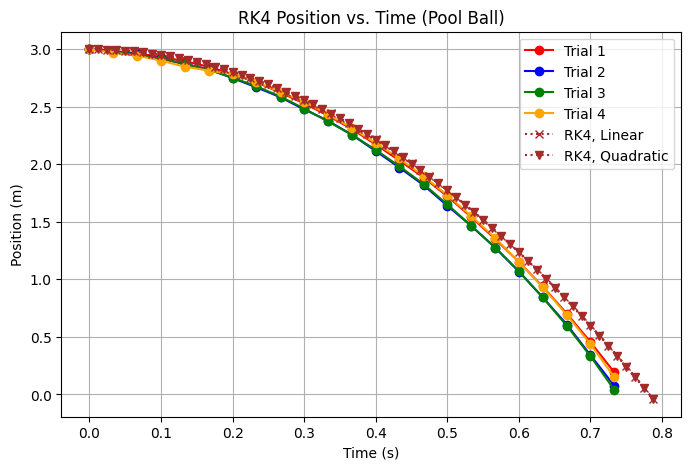

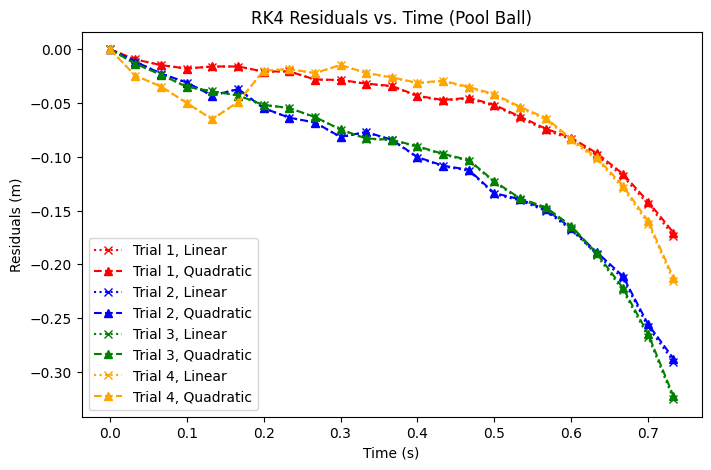

In [27]:
# RK4 estimation of linear drag
rk4_linear_t, rk4_linear_y = rk_fall(3, dt, m, "linear", b, "rk4")

# RK4 estimation of quadratic drag
rk4_quadratic_t, rk4_quadratic_y = rk_fall(3, dt, m, "quadratic", c, "rk4")

# determine the better match
# use interpolate to get consistent data throughout
rk4_linear_y_interp = np.interp(time1, rk4_linear_t, rk4_linear_y)
rk4_quadratic_y_interp = np.interp(time1, rk4_quadratic_t, rk4_quadratic_y)

# find the residuals
rk4_y1l_residuals, rk4_y1q_residuals = pos1 - rk4_linear_y_interp, pos1 - rk4_quadratic_y_interp
rk4_y2l_residuals, rk4_y2q_residuals = pos2 - rk4_linear_y_interp, pos2 - rk4_quadratic_y_interp
rk4_y3l_residuals, rk4_y3q_residuals = pos3 - rk4_linear_y_interp, pos3 - rk4_quadratic_y_interp
rk4_y4l_residuals, rk4_y4q_residuals = pos4 - rk4_linear_y_interp, pos4 - rk4_quadratic_y_interp
# find the root mean square error
rk4_rmse_linear1 = np.sqrt(np.mean((rk4_y1l_residuals) ** 2))
rk4_rmse_quadratic1 = np.sqrt(np.mean((rk4_y1q_residuals) ** 2))
rk4_rmse_linear2 = np.sqrt(np.mean((rk4_y2l_residuals) ** 2))
rk4_rmse_quadratic2 = np.sqrt(np.mean((rk4_y2q_residuals) ** 2))
rk4_rmse_linear3 = np.sqrt(np.mean((rk4_y3l_residuals) ** 2))
rk4_rmse_quadratic3 = np.sqrt(np.mean((rk4_y3q_residuals) ** 2))
rk4_rmse_linear4 = np.sqrt(np.mean((rk4_y4l_residuals) ** 2))
rk4_rmse_quadratic4 = np.sqrt(np.mean((rk4_y4q_residuals) ** 2))

print(f"RMSE for linear model Trial 1: {rk4_rmse_linear1:.4f}")
print(f"RMSE for quadratic model Trial 1: {rk4_rmse_quadratic1:.4f}")
print(f"RMSE for linear model Trial 2: {rk4_rmse_linear2:.4f}")
print(f"RMSE for quadratic model Trial 2: {rk4_rmse_quadratic2:.4f}")
print(f"RMSE for linear model Trial 3: {rk4_rmse_linear3:.4f}")
print(f"RMSE for quadratic model Trial 3: {rk4_rmse_quadratic3:.4f}")
print(f"RMSE for linear model Trial 4: {rk4_rmse_linear4:.4f}")
print(f"RMSE for quadratic model Trial 4: {rk4_rmse_quadratic4:.4f}")

# Create the plot
plt.figure(figsize=(8, 5))
# drop 1
plt.plot(time1, pos1, label = 'Trial 1', marker = 'o', ls = '-', color = 'red')
# drop 2
plt.plot(time2, pos2, label = 'Trial 2', marker = 'o', ls = '-', color = 'blue')
# drop 3
plt.plot(time3, pos3, label = 'Trial 3', marker = 'o', ls = '-', color = 'green')
# drop 4
plt.plot(time4, pos4, label = 'Trial 4', marker = 'o', ls = '-', color = 'orange')

plt.plot(rk4_linear_t, rk4_linear_y, label = f'RK4, Linear', marker = 'x', ls = ':', color = 'brown')
plt.plot(rk4_quadratic_t, rk4_quadratic_y, label = f'RK4, Quadratic', marker = 'v', ls = ':', color = 'brown')

# Format the plot
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('RK4 Position vs. Time (Pool Ball)')
plt.legend()
plt.grid(True)
plt.show()

# plot residuals with time
plt.figure(figsize=(8, 5))
plt.plot(time1, rk4_y1l_residuals, label = 'Trial 1, Linear', marker = 'x', ls = ':', color = 'red')
plt.plot(time1, rk4_y1q_residuals, label = 'Trial 1, Quadratic', marker = '^', ls = '--', color = 'red')
plt.plot(time2, rk4_y2l_residuals, label = 'Trial 2, Linear', marker = 'x', ls = ':', color = 'blue')
plt.plot(time2, rk4_y2q_residuals, label = 'Trial 2, Quadratic', marker = '^', ls = '--', color = 'blue')
plt.plot(time3, rk4_y3l_residuals, label = 'Trial 3, Linear', marker = 'x', ls = ':', color = 'green')
plt.plot(time3, rk4_y3q_residuals, label = 'Trial 3, Quadratic', marker = '^', ls = '--', color = 'green')
plt.plot(time4, rk4_y4l_residuals, label = 'Trial 4, Linear', marker = 'x', ls = ':', color = 'orange')
plt.plot(time4, rk4_y4q_residuals, label = 'Trial 4, Quadratic', marker = '^', ls = '--', color = 'orange')
plt.xlabel('Time (s)')
plt.ylabel('Residuals (m)')
plt.title('RK4 Residuals vs. Time (Pool Ball)')
plt.legend()

BELOW IS THE DATA FOR THE THREE OTHER BALLS - THE CODE IS IDENTICAL TO THE ONES ABOVE


Golf Ball Data

In [28]:
# extract times and positions using column indexing
time1, pos1 = df_golf['t'], df_golf['x1']
time2, pos2 = df_golf['t'], df_golf['x2']
time3, pos3 = df_golf['t'], df_golf['x3']
time4, pos4 = df_golf['t'], df_golf['x4']

# establish parameters for beach ball
m = 0.046
b = 3.85e-4
c = 6.82e-6

RMSE for linear model Trial 1: 0.1964
RMSE for quadratic model Trial 1: 0.1948
RMSE for linear model Trial 2: 0.1425
RMSE for quadratic model Trial 2: 0.1408
RMSE for linear model Trial 3: 0.1904
RMSE for quadratic model Trial 3: 0.1888
RMSE for linear model Trial 4: 0.2297
RMSE for quadratic model Trial 4: 0.2281


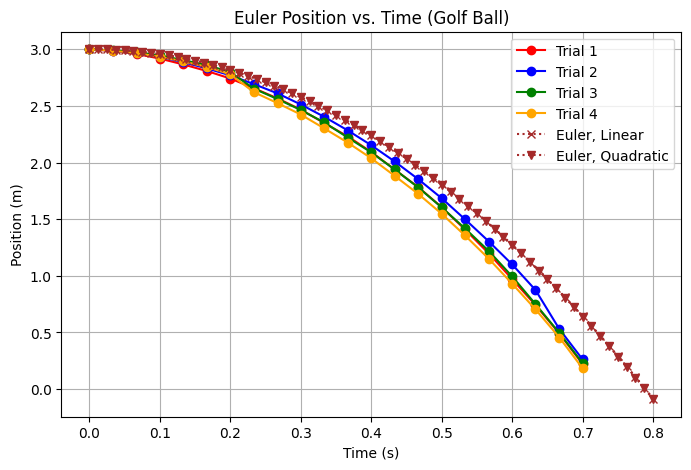

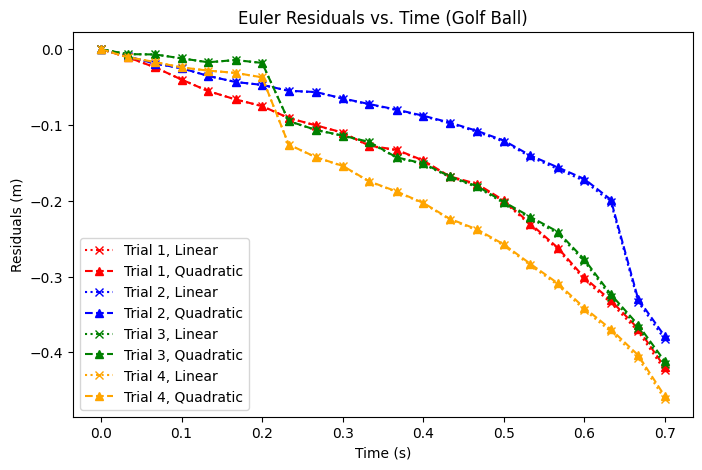

In [29]:
# Euler estimation of linear drag
euler_linear_t, euler_linear_y = euler(3, dt, m, "linear", coeff=b)

# Euler estimation of quadratic drag
euler_quadratic_t, euler_quadratic_y = euler(3, dt, m, "quadratic", coeff=c)

# determine the better match
# use interpolate to get consistent data throughout
euler_linear_y_interp = np.interp(time1, euler_linear_t, euler_linear_y)
euler_quadratic_y_interp = np.interp(time1, euler_quadratic_t, euler_quadratic_y)

# find the residuals
euler_y1l_residuals, euler_y1q_residuals = pos1 - euler_linear_y_interp, pos1 - euler_quadratic_y_interp
euler_y2l_residuals, euler_y2q_residuals = pos2 - euler_linear_y_interp, pos2 - euler_quadratic_y_interp
euler_y3l_residuals, euler_y3q_residuals = pos3 - euler_linear_y_interp, pos3 - euler_quadratic_y_interp
euler_y4l_residuals, euler_y4q_residuals = pos4 - euler_linear_y_interp, pos4 - euler_quadratic_y_interp
# find the root mean square error
euler_rmse_linear1 = np.sqrt(np.mean((euler_y1l_residuals) ** 2))
euler_rmse_quadratic1 = np.sqrt(np.mean((euler_y1q_residuals) ** 2))
euler_rmse_linear2 = np.sqrt(np.mean((euler_y2l_residuals) ** 2))
euler_rmse_quadratic2 = np.sqrt(np.mean((euler_y2q_residuals) ** 2))
euler_rmse_linear3 = np.sqrt(np.mean((euler_y3l_residuals) ** 2))
euler_rmse_quadratic3 = np.sqrt(np.mean((euler_y3q_residuals) ** 2))
euler_rmse_linear4 = np.sqrt(np.mean((euler_y4l_residuals) ** 2))
euler_rmse_quadratic4 = np.sqrt(np.mean((euler_y4q_residuals) ** 2))

print(f"RMSE for linear model Trial 1: {euler_rmse_linear1:.4f}")
print(f"RMSE for quadratic model Trial 1: {euler_rmse_quadratic1:.4f}")
print(f"RMSE for linear model Trial 2: {euler_rmse_linear2:.4f}")
print(f"RMSE for quadratic model Trial 2: {euler_rmse_quadratic2:.4f}")
print(f"RMSE for linear model Trial 3: {euler_rmse_linear3:.4f}")
print(f"RMSE for quadratic model Trial 3: {euler_rmse_quadratic3:.4f}")
print(f"RMSE for linear model Trial 4: {euler_rmse_linear4:.4f}")
print(f"RMSE for quadratic model Trial 4: {euler_rmse_quadratic4:.4f}")

# Create the plot
plt.figure(figsize=(8, 5))
# drop 1
plt.plot(time1, pos1, label = 'Trial 1', marker = 'o', ls = '-', color = 'red')
# drop 2
plt.plot(time2, pos2, label = 'Trial 2', marker = 'o', ls = '-', color = 'blue')
# drop 3
plt.plot(time3, pos3, label = 'Trial 3', marker = 'o', ls = '-', color = 'green')
# drop 4
plt.plot(time4, pos4, label = 'Trial 4', marker = 'o', ls = '-', color = 'orange')

plt.plot(euler_linear_t, euler_linear_y, label = f'Euler, Linear', marker = 'x', ls = ':', color = 'brown')
plt.plot(euler_quadratic_t, euler_quadratic_y, label = f'Euler, Quadratic', marker = 'v', ls = ':', color = 'brown')

# Format the plot
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Euler Position vs. Time (Golf Ball)')
plt.legend()
plt.grid(True)
plt.show()

# plot residuals with time
plt.figure(figsize=(8, 5))
plt.plot(time1, euler_y1l_residuals, label = 'Trial 1, Linear', marker = 'x', ls = ':', color = 'red')
plt.plot(time1, euler_y1q_residuals, label = 'Trial 1, Quadratic', marker = '^', ls = '--', color = 'red')
plt.plot(time2, euler_y2l_residuals, label = 'Trial 2, Linear', marker = 'x', ls = ':', color = 'blue')
plt.plot(time2, euler_y2q_residuals, label = 'Trial 2, Quadratic', marker = '^', ls = '--', color = 'blue')
plt.plot(time3, euler_y3l_residuals, label = 'Trial 3, Linear', marker = 'x', ls = ':', color = 'green')
plt.plot(time3, euler_y3q_residuals, label = 'Trial 3, Quadratic', marker = '^', ls = '--', color = 'green')
plt.plot(time3, euler_y4l_residuals, label = 'Trial 4, Linear', marker = 'x', ls = ':', color = 'orange')
plt.plot(time3, euler_y4q_residuals, label = 'Trial 4, Quadratic', marker = '^', ls = '--', color = 'orange')
plt.xlabel('Time (s)')
plt.ylabel('Residuals (m)')
plt.title('Euler Residuals vs. Time (Golf Ball)')
plt.legend()

RMSE for linear model Trial 1: 0.1719
RMSE for quadratic model Trial 1: 0.1702
RMSE for linear model Trial 2: 0.1193
RMSE for quadratic model Trial 2: 0.1176
RMSE for linear model Trial 3: 0.1661
RMSE for quadratic model Trial 3: 0.1643
RMSE for linear model Trial 4: 0.2050
RMSE for quadratic model Trial 4: 0.2033


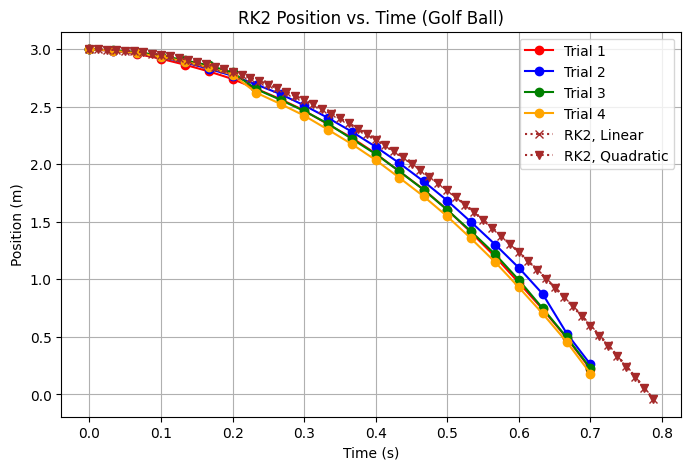

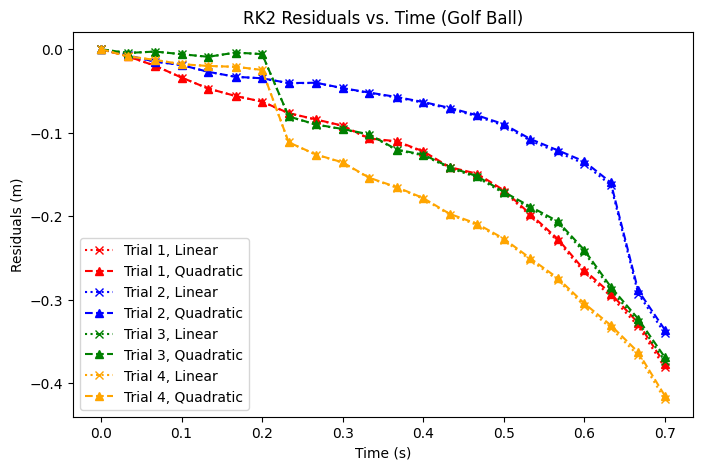

In [30]:
# RK2 estimation of linear drag
rk2_linear_t, rk2_linear_y = rk_fall(3, dt, m, "linear", b, "rk2")

# RK2 estimation of quadratic drag
rk2_quadratic_t, rk2_quadratic_y = rk_fall(3, dt, m, "quadratic", c, "rk2")

# determine the better match
# use interpolate to get consistent data throughout
rk2_linear_y_interp = np.interp(time1, rk2_linear_t, rk2_linear_y)
rk2_quadratic_y_interp = np.interp(time1, rk2_quadratic_t, rk2_quadratic_y)

# find the residuals
rk2_y1l_residuals, rk2_y1q_residuals = pos1 - rk2_linear_y_interp, pos1 - rk2_quadratic_y_interp
rk2_y2l_residuals, rk2_y2q_residuals = pos2 - rk2_linear_y_interp, pos2 - rk2_quadratic_y_interp
rk2_y3l_residuals, rk2_y3q_residuals = pos3 - rk2_linear_y_interp, pos3 - rk2_quadratic_y_interp
rk2_y4l_residuals, rk2_y4q_residuals = pos4 - rk2_linear_y_interp, pos4 - rk2_quadratic_y_interp
# find the root mean square error
rk2_rmse_linear1 = np.sqrt(np.mean((rk2_y1l_residuals) ** 2))
rk2_rmse_quadratic1 = np.sqrt(np.mean((rk2_y1q_residuals) ** 2))
rk2_rmse_linear2 = np.sqrt(np.mean((rk2_y2l_residuals) ** 2))
rk2_rmse_quadratic2 = np.sqrt(np.mean((rk2_y2q_residuals) ** 2))
rk2_rmse_linear3 = np.sqrt(np.mean((rk2_y3l_residuals) ** 2))
rk2_rmse_quadratic3 = np.sqrt(np.mean((rk2_y3q_residuals) ** 2))
rk2_rmse_linear4 = np.sqrt(np.mean((rk2_y4l_residuals) ** 2))
rk2_rmse_quadratic4 = np.sqrt(np.mean((rk2_y4q_residuals) ** 2))

print(f"RMSE for linear model Trial 1: {rk2_rmse_linear1:.4f}")
print(f"RMSE for quadratic model Trial 1: {rk2_rmse_quadratic1:.4f}")
print(f"RMSE for linear model Trial 2: {rk2_rmse_linear2:.4f}")
print(f"RMSE for quadratic model Trial 2: {rk2_rmse_quadratic2:.4f}")
print(f"RMSE for linear model Trial 3: {rk2_rmse_linear3:.4f}")
print(f"RMSE for quadratic model Trial 3: {rk2_rmse_quadratic3:.4f}")
print(f"RMSE for linear model Trial 4: {rk2_rmse_linear4:.4f}")
print(f"RMSE for quadratic model Trial 4: {rk2_rmse_quadratic4:.4f}")

# Create the plot
plt.figure(figsize=(8, 5))
# drop 1
plt.plot(time1, pos1, label = 'Trial 1', marker = 'o', ls = '-', color = 'red')
# drop 2
plt.plot(time2, pos2, label = 'Trial 2', marker = 'o', ls = '-', color = 'blue')
# drop 3
plt.plot(time3, pos3, label = 'Trial 3', marker = 'o', ls = '-', color = 'green')
# drop 4
plt.plot(time4, pos4, label = 'Trial 4', marker = 'o', ls = '-', color = 'orange')

plt.plot(rk2_linear_t, rk2_linear_y, label = f'RK2, Linear', marker = 'x', ls = ':', color = 'brown')
plt.plot(rk2_quadratic_t, rk2_quadratic_y, label = f'RK2, Quadratic', marker = 'v', ls = ':', color = 'brown')

# Format the plot
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('RK2 Position vs. Time (Golf Ball)')
plt.legend()
plt.grid(True)
plt.show()

# plot residuals with time
plt.figure(figsize=(8, 5))
plt.plot(time1, rk2_y1l_residuals, label = 'Trial 1, Linear', marker = 'x', ls = ':', color = 'red')
plt.plot(time1, rk2_y1q_residuals, label = 'Trial 1, Quadratic', marker = '^', ls = '--', color = 'red')
plt.plot(time2, rk2_y2l_residuals, label = 'Trial 2, Linear', marker = 'x', ls = ':', color = 'blue')
plt.plot(time2, rk2_y2q_residuals, label = 'Trial 2, Quadratic', marker = '^', ls = '--', color = 'blue')
plt.plot(time3, rk2_y3l_residuals, label = 'Trial 3, Linear', marker = 'x', ls = ':', color = 'green')
plt.plot(time3, rk2_y3q_residuals, label = 'Trial 3, Quadratic', marker = '^', ls = '--', color = 'green')
plt.plot(time4, rk2_y4l_residuals, label = 'Trial 4, Linear', marker = 'x', ls = ':', color = 'orange')
plt.plot(time4, rk2_y4q_residuals, label = 'Trial 4, Quadratic', marker = '^', ls = '--', color = 'orange')
plt.xlabel('Time (s)')
plt.ylabel('Residuals (m)')
plt.title('RK2 Residuals vs. Time (Golf Ball)')
plt.legend()

RMSE for linear model Trial 1: 0.1719
RMSE for quadratic model Trial 1: 0.1702
RMSE for linear model Trial 2: 0.1193
RMSE for quadratic model Trial 2: 0.1176
RMSE for linear model Trial 3: 0.1661
RMSE for quadratic model Trial 3: 0.1643
RMSE for linear model Trial 4: 0.2050
RMSE for quadratic model Trial 4: 0.2033


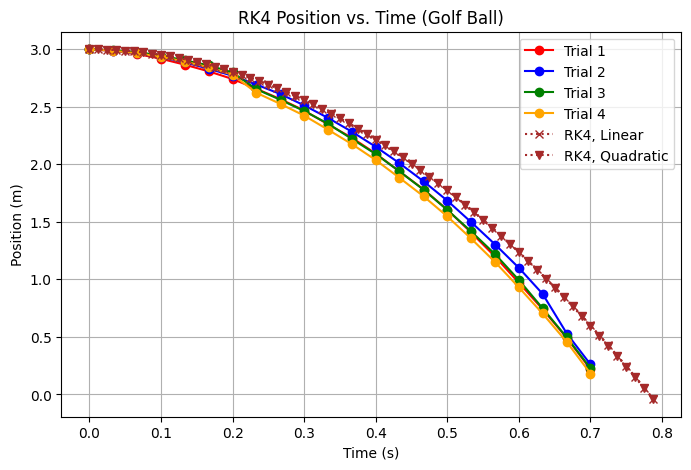

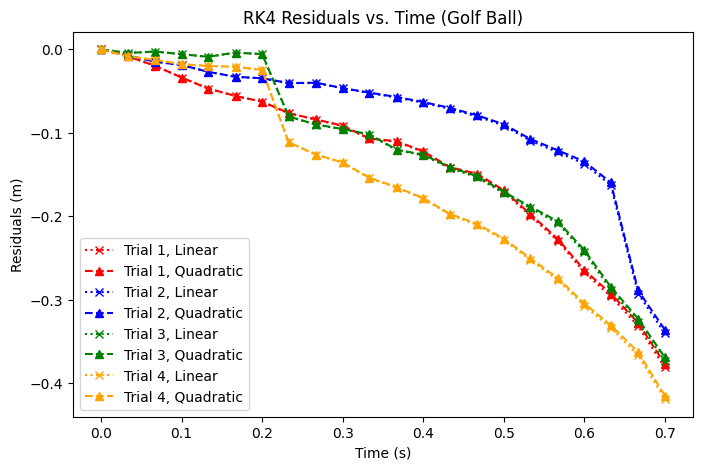

In [31]:
# RK4 estimation of linear drag
rk4_linear_t, rk4_linear_y = rk_fall(3, dt, m, "linear", b, "rk4")

# RK4 estimation of quadratic drag
rk4_quadratic_t, rk4_quadratic_y = rk_fall(3, dt, m, "quadratic", c, "rk4")

# determine the better match
# use interpolate to get consistent data throughout
rk4_linear_y_interp = np.interp(time1, rk4_linear_t, rk4_linear_y)
rk4_quadratic_y_interp = np.interp(time1, rk4_quadratic_t, rk4_quadratic_y)

# find the residuals
rk4_y1l_residuals, rk4_y1q_residuals = pos1 - rk4_linear_y_interp, pos1 - rk4_quadratic_y_interp
rk4_y2l_residuals, rk4_y2q_residuals = pos2 - rk4_linear_y_interp, pos2 - rk4_quadratic_y_interp
rk4_y3l_residuals, rk4_y3q_residuals = pos3 - rk4_linear_y_interp, pos3 - rk4_quadratic_y_interp
rk4_y4l_residuals, rk4_y4q_residuals = pos4 - rk4_linear_y_interp, pos4 - rk4_quadratic_y_interp
# find the root mean square error
rk4_rmse_linear1 = np.sqrt(np.mean((rk4_y1l_residuals) ** 2))
rk4_rmse_quadratic1 = np.sqrt(np.mean((rk4_y1q_residuals) ** 2))
rk4_rmse_linear2 = np.sqrt(np.mean((rk4_y2l_residuals) ** 2))
rk4_rmse_quadratic2 = np.sqrt(np.mean((rk4_y2q_residuals) ** 2))
rk4_rmse_linear3 = np.sqrt(np.mean((rk4_y3l_residuals) ** 2))
rk4_rmse_quadratic3 = np.sqrt(np.mean((rk4_y3q_residuals) ** 2))
rk4_rmse_linear4 = np.sqrt(np.mean((rk4_y4l_residuals) ** 2))
rk4_rmse_quadratic4 = np.sqrt(np.mean((rk4_y4q_residuals) ** 2))

print(f"RMSE for linear model Trial 1: {rk4_rmse_linear1:.4f}")
print(f"RMSE for quadratic model Trial 1: {rk4_rmse_quadratic1:.4f}")
print(f"RMSE for linear model Trial 2: {rk4_rmse_linear2:.4f}")
print(f"RMSE for quadratic model Trial 2: {rk4_rmse_quadratic2:.4f}")
print(f"RMSE for linear model Trial 3: {rk4_rmse_linear3:.4f}")
print(f"RMSE for quadratic model Trial 3: {rk4_rmse_quadratic3:.4f}")
print(f"RMSE for linear model Trial 4: {rk4_rmse_linear4:.4f}")
print(f"RMSE for quadratic model Trial 4: {rk4_rmse_quadratic4:.4f}")

# Create the plot
plt.figure(figsize=(8, 5))
# drop 1
plt.plot(time1, pos1, label = 'Trial 1', marker = 'o', ls = '-', color = 'red')
# drop 2
plt.plot(time2, pos2, label = 'Trial 2', marker = 'o', ls = '-', color = 'blue')
# drop 3
plt.plot(time3, pos3, label = 'Trial 3', marker = 'o', ls = '-', color = 'green')
# drop 4
plt.plot(time4, pos4, label = 'Trial 4', marker = 'o', ls = '-', color = 'orange')

plt.plot(rk4_linear_t, rk4_linear_y, label = f'RK4, Linear', marker = 'x', ls = ':', color = 'brown')
plt.plot(rk4_quadratic_t, rk4_quadratic_y, label = f'RK4, Quadratic', marker = 'v', ls = ':', color = 'brown')

# Format the plot
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('RK4 Position vs. Time (Golf Ball)')
plt.legend()
plt.grid(True)
plt.show()

# plot residuals with time
plt.figure(figsize=(8, 5))
plt.plot(time1, rk4_y1l_residuals, label = 'Trial 1, Linear', marker = 'x', ls = ':', color = 'red')
plt.plot(time1, rk4_y1q_residuals, label = 'Trial 1, Quadratic', marker = '^', ls = '--', color = 'red')
plt.plot(time2, rk4_y2l_residuals, label = 'Trial 2, Linear', marker = 'x', ls = ':', color = 'blue')
plt.plot(time2, rk4_y2q_residuals, label = 'Trial 2, Quadratic', marker = '^', ls = '--', color = 'blue')
plt.plot(time3, rk4_y3l_residuals, label = 'Trial 3, Linear', marker = 'x', ls = ':', color = 'green')
plt.plot(time3, rk4_y3q_residuals, label = 'Trial 3, Quadratic', marker = '^', ls = '--', color = 'green')
plt.plot(time4, rk4_y4l_residuals, label = 'Trial 4, Linear', marker = 'x', ls = ':', color = 'orange')
plt.plot(time4, rk4_y4q_residuals, label = 'Trial 4, Quadratic', marker = '^', ls = '--', color = 'orange')
plt.xlabel('Time (s)')
plt.ylabel('Residuals (m)')
plt.title('RK4 Residuals vs. Time (Golf Ball)')
plt.legend()

Tiny Ball Data

In [32]:
# extract times and positions using column indexing
time1, pos1 = df_tiny['t'], df_tiny['x1']
time2, pos2 = df_tiny['t'], df_tiny['x2']
time3, pos3 = df_tiny['t'], df_tiny['x3']
time4, pos4 = df_tiny['t'], df_tiny['x4']

# establish parameters for beach ball
m = 0.004
b = 3.76e-5
c = 2.13e-6

RMSE for linear model Trial 1: 0.3951
RMSE for quadratic model Trial 1: 0.3938
RMSE for linear model Trial 2: 0.3096
RMSE for quadratic model Trial 2: 0.3083
RMSE for linear model Trial 3: 0.3502
RMSE for quadratic model Trial 3: 0.3489
RMSE for linear model Trial 4: 0.3489
RMSE for quadratic model Trial 4: 0.3476


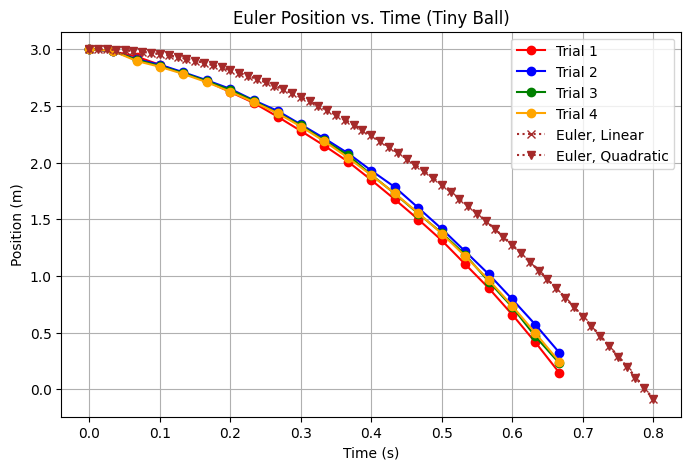

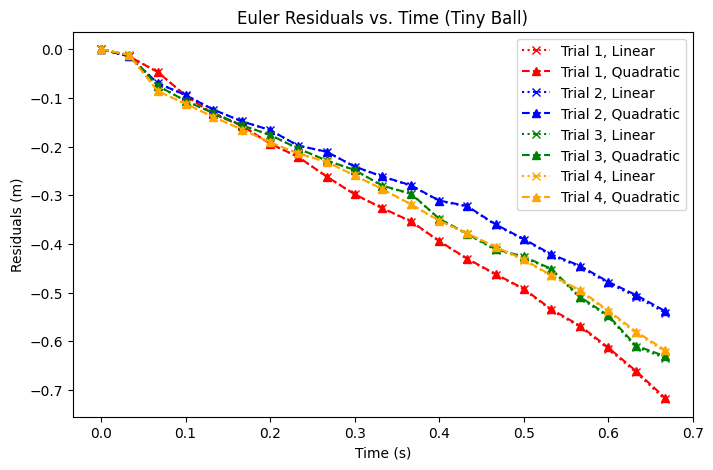

In [33]:
# Euler estimation of linear drag
euler_linear_t, euler_linear_y = euler(3, dt, m, "linear", coeff=b)

# Euler estimation of quadratic drag
euler_quadratic_t, euler_quadratic_y = euler(3, dt, m, "quadratic", coeff=c)

# determine the better match
# use interpolate to get consistent data throughout
euler_linear_y_interp = np.interp(time1, euler_linear_t, euler_linear_y)
euler_quadratic_y_interp = np.interp(time1, euler_quadratic_t, euler_quadratic_y)

# find the residuals
euler_y1l_residuals, euler_y1q_residuals = pos1 - euler_linear_y_interp, pos1 - euler_quadratic_y_interp
euler_y2l_residuals, euler_y2q_residuals = pos2 - euler_linear_y_interp, pos2 - euler_quadratic_y_interp
euler_y3l_residuals, euler_y3q_residuals = pos3 - euler_linear_y_interp, pos3 - euler_quadratic_y_interp
euler_y4l_residuals, euler_y4q_residuals = pos4 - euler_linear_y_interp, pos4 - euler_quadratic_y_interp
# find the root mean square error
euler_rmse_linear1 = np.sqrt(np.mean((euler_y1l_residuals) ** 2))
euler_rmse_quadratic1 = np.sqrt(np.mean((euler_y1q_residuals) ** 2))
euler_rmse_linear2 = np.sqrt(np.mean((euler_y2l_residuals) ** 2))
euler_rmse_quadratic2 = np.sqrt(np.mean((euler_y2q_residuals) ** 2))
euler_rmse_linear3 = np.sqrt(np.mean((euler_y3l_residuals) ** 2))
euler_rmse_quadratic3 = np.sqrt(np.mean((euler_y3q_residuals) ** 2))
euler_rmse_linear4 = np.sqrt(np.mean((euler_y4l_residuals) ** 2))
euler_rmse_quadratic4 = np.sqrt(np.mean((euler_y4q_residuals) ** 2))

print(f"RMSE for linear model Trial 1: {euler_rmse_linear1:.4f}")
print(f"RMSE for quadratic model Trial 1: {euler_rmse_quadratic1:.4f}")
print(f"RMSE for linear model Trial 2: {euler_rmse_linear2:.4f}")
print(f"RMSE for quadratic model Trial 2: {euler_rmse_quadratic2:.4f}")
print(f"RMSE for linear model Trial 3: {euler_rmse_linear3:.4f}")
print(f"RMSE for quadratic model Trial 3: {euler_rmse_quadratic3:.4f}")
print(f"RMSE for linear model Trial 4: {euler_rmse_linear4:.4f}")
print(f"RMSE for quadratic model Trial 4: {euler_rmse_quadratic4:.4f}")

# Create the plot
plt.figure(figsize=(8, 5))
# drop 1
plt.plot(time1, pos1, label = 'Trial 1', marker = 'o', ls = '-', color = 'red')
# drop 2
plt.plot(time2, pos2, label = 'Trial 2', marker = 'o', ls = '-', color = 'blue')
# drop 3
plt.plot(time3, pos3, label = 'Trial 3', marker = 'o', ls = '-', color = 'green')
# drop 4
plt.plot(time4, pos4, label = 'Trial 4', marker = 'o', ls = '-', color = 'orange')

plt.plot(euler_linear_t, euler_linear_y, label = f'Euler, Linear', marker = 'x', ls = ':', color = 'brown')
plt.plot(euler_quadratic_t, euler_quadratic_y, label = f'Euler, Quadratic', marker = 'v', ls = ':', color = 'brown')

# Format the plot
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('Euler Position vs. Time (Tiny Ball)')
plt.legend()
plt.grid(True)
plt.show()

# plot residuals with time
plt.figure(figsize=(8, 5))
plt.plot(time1, euler_y1l_residuals, label = 'Trial 1, Linear', marker = 'x', ls = ':', color = 'red')
plt.plot(time1, euler_y1q_residuals, label = 'Trial 1, Quadratic', marker = '^', ls = '--', color = 'red')
plt.plot(time2, euler_y2l_residuals, label = 'Trial 2, Linear', marker = 'x', ls = ':', color = 'blue')
plt.plot(time2, euler_y2q_residuals, label = 'Trial 2, Quadratic', marker = '^', ls = '--', color = 'blue')
plt.plot(time3, euler_y3l_residuals, label = 'Trial 3, Linear', marker = 'x', ls = ':', color = 'green')
plt.plot(time3, euler_y3q_residuals, label = 'Trial 3, Quadratic', marker = '^', ls = '--', color = 'green')
plt.plot(time3, euler_y4l_residuals, label = 'Trial 4, Linear', marker = 'x', ls = ':', color = 'orange')
plt.plot(time3, euler_y4q_residuals, label = 'Trial 4, Quadratic', marker = '^', ls = '--', color = 'orange')
plt.xlabel('Time (s)')
plt.ylabel('Residuals (m)')
plt.title('Euler Residuals vs. Time (Tiny Ball)')
plt.legend()

RMSE for linear model Trial 1: 0.3713
RMSE for quadratic model Trial 1: 0.3699
RMSE for linear model Trial 2: 0.2858
RMSE for quadratic model Trial 2: 0.2844
RMSE for linear model Trial 3: 0.3265
RMSE for quadratic model Trial 3: 0.3250
RMSE for linear model Trial 4: 0.3252
RMSE for quadratic model Trial 4: 0.3238


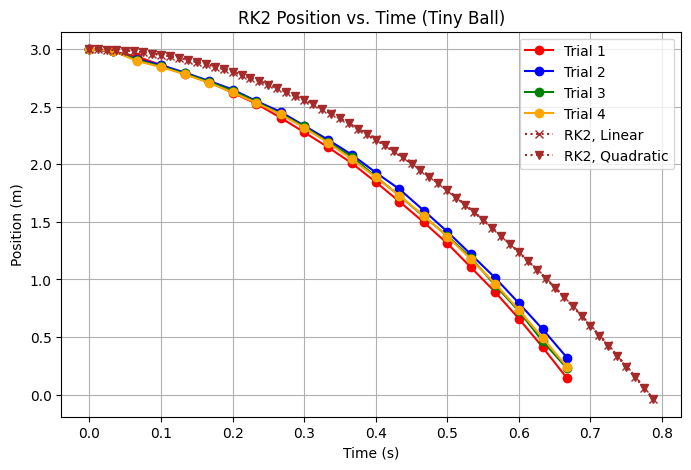

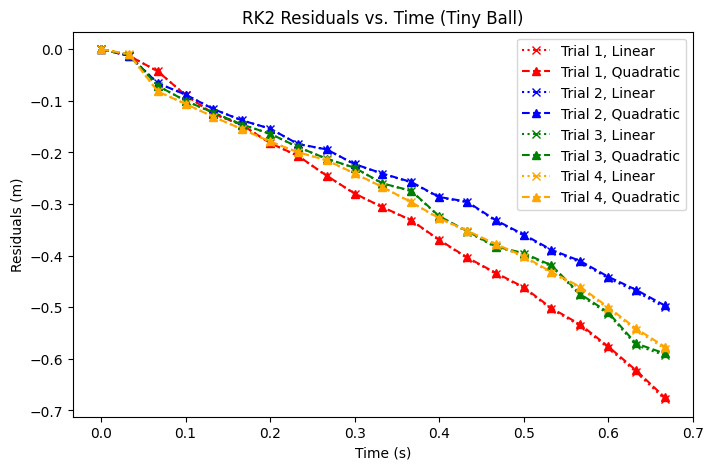

In [34]:
# RK2 estimation of linear drag
rk2_linear_t, rk2_linear_y = rk_fall(3, dt, m, "linear", b, "rk2")

# RK2 estimation of quadratic drag
rk2_quadratic_t, rk2_quadratic_y = rk_fall(3, dt, m, "quadratic", c, "rk2")

# determine the better match
# use interpolate to get consistent data throughout
rk2_linear_y_interp = np.interp(time1, rk2_linear_t, rk2_linear_y)
rk2_quadratic_y_interp = np.interp(time1, rk2_quadratic_t, rk2_quadratic_y)

# find the residuals
rk2_y1l_residuals, rk2_y1q_residuals = pos1 - rk2_linear_y_interp, pos1 - rk2_quadratic_y_interp
rk2_y2l_residuals, rk2_y2q_residuals = pos2 - rk2_linear_y_interp, pos2 - rk2_quadratic_y_interp
rk2_y3l_residuals, rk2_y3q_residuals = pos3 - rk2_linear_y_interp, pos3 - rk2_quadratic_y_interp
rk2_y4l_residuals, rk2_y4q_residuals = pos4 - rk2_linear_y_interp, pos4 - rk2_quadratic_y_interp
# find the root mean square error
rk2_rmse_linear1 = np.sqrt(np.mean((rk2_y1l_residuals) ** 2))
rk2_rmse_quadratic1 = np.sqrt(np.mean((rk2_y1q_residuals) ** 2))
rk2_rmse_linear2 = np.sqrt(np.mean((rk2_y2l_residuals) ** 2))
rk2_rmse_quadratic2 = np.sqrt(np.mean((rk2_y2q_residuals) ** 2))
rk2_rmse_linear3 = np.sqrt(np.mean((rk2_y3l_residuals) ** 2))
rk2_rmse_quadratic3 = np.sqrt(np.mean((rk2_y3q_residuals) ** 2))
rk2_rmse_linear4 = np.sqrt(np.mean((rk2_y4l_residuals) ** 2))
rk2_rmse_quadratic4 = np.sqrt(np.mean((rk2_y4q_residuals) ** 2))

print(f"RMSE for linear model Trial 1: {rk2_rmse_linear1:.4f}")
print(f"RMSE for quadratic model Trial 1: {rk2_rmse_quadratic1:.4f}")
print(f"RMSE for linear model Trial 2: {rk2_rmse_linear2:.4f}")
print(f"RMSE for quadratic model Trial 2: {rk2_rmse_quadratic2:.4f}")
print(f"RMSE for linear model Trial 3: {rk2_rmse_linear3:.4f}")
print(f"RMSE for quadratic model Trial 3: {rk2_rmse_quadratic3:.4f}")
print(f"RMSE for linear model Trial 4: {rk2_rmse_linear4:.4f}")
print(f"RMSE for quadratic model Trial 4: {rk2_rmse_quadratic4:.4f}")

# Create the plot
plt.figure(figsize=(8, 5))
# drop 1
plt.plot(time1, pos1, label = 'Trial 1', marker = 'o', ls = '-', color = 'red')
# drop 2
plt.plot(time2, pos2, label = 'Trial 2', marker = 'o', ls = '-', color = 'blue')
# drop 3
plt.plot(time3, pos3, label = 'Trial 3', marker = 'o', ls = '-', color = 'green')
# drop 4
plt.plot(time4, pos4, label = 'Trial 4', marker = 'o', ls = '-', color = 'orange')

plt.plot(rk2_linear_t, rk2_linear_y, label = f'RK2, Linear', marker = 'x', ls = ':', color = 'brown')
plt.plot(rk2_quadratic_t, rk2_quadratic_y, label = f'RK2, Quadratic', marker = 'v', ls = ':', color = 'brown')

# Format the plot
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('RK2 Position vs. Time (Tiny Ball)')
plt.legend()
plt.grid(True)
plt.show()

# plot residuals with time
plt.figure(figsize=(8, 5))
plt.plot(time1, rk2_y1l_residuals, label = 'Trial 1, Linear', marker = 'x', ls = ':', color = 'red')
plt.plot(time1, rk2_y1q_residuals, label = 'Trial 1, Quadratic', marker = '^', ls = '--', color = 'red')
plt.plot(time2, rk2_y2l_residuals, label = 'Trial 2, Linear', marker = 'x', ls = ':', color = 'blue')
plt.plot(time2, rk2_y2q_residuals, label = 'Trial 2, Quadratic', marker = '^', ls = '--', color = 'blue')
plt.plot(time3, rk2_y3l_residuals, label = 'Trial 3, Linear', marker = 'x', ls = ':', color = 'green')
plt.plot(time3, rk2_y3q_residuals, label = 'Trial 3, Quadratic', marker = '^', ls = '--', color = 'green')
plt.plot(time4, rk2_y4l_residuals, label = 'Trial 4, Linear', marker = 'x', ls = ':', color = 'orange')
plt.plot(time4, rk2_y4q_residuals, label = 'Trial 4, Quadratic', marker = '^', ls = '--', color = 'orange')
plt.xlabel('Time (s)')
plt.ylabel('Residuals (m)')
plt.title('RK2 Residuals vs. Time (Tiny Ball)')
plt.legend()

RMSE for linear model Trial 1: 0.3713
RMSE for quadratic model Trial 1: 0.3699
RMSE for linear model Trial 2: 0.2858
RMSE for quadratic model Trial 2: 0.2844
RMSE for linear model Trial 3: 0.3265
RMSE for quadratic model Trial 3: 0.3250
RMSE for linear model Trial 4: 0.3252
RMSE for quadratic model Trial 4: 0.3238


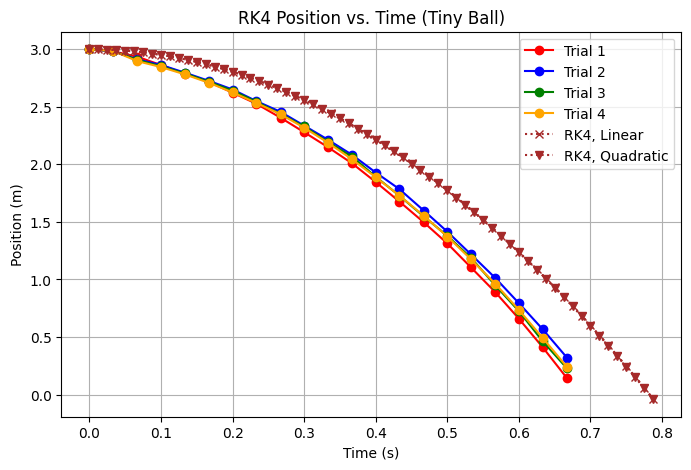

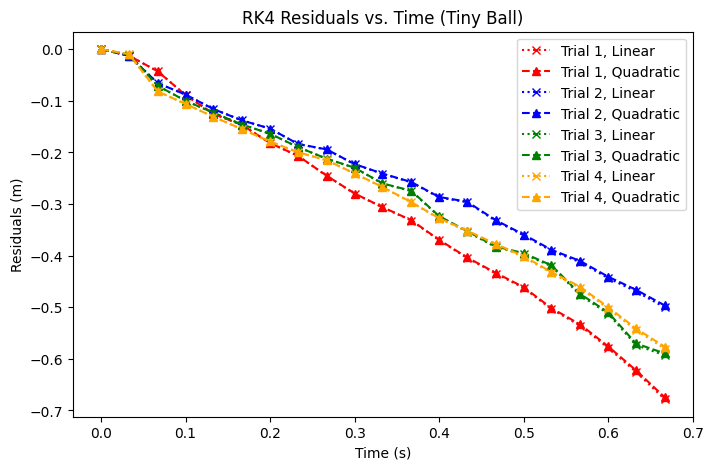

In [35]:
# RK4 estimation of linear drag
rk4_linear_t, rk4_linear_y = rk_fall(3, dt, m, "linear", b, "rk4")

# RK4 estimation of quadratic drag
rk4_quadratic_t, rk4_quadratic_y = rk_fall(3, dt, m, "quadratic", c, "rk4")

# determine the better match
# use interpolate to get consistent data throughout
rk4_linear_y_interp = np.interp(time1, rk4_linear_t, rk4_linear_y)
rk4_quadratic_y_interp = np.interp(time1, rk4_quadratic_t, rk4_quadratic_y)

# find the residuals
rk4_y1l_residuals, rk4_y1q_residuals = pos1 - rk4_linear_y_interp, pos1 - rk4_quadratic_y_interp
rk4_y2l_residuals, rk4_y2q_residuals = pos2 - rk4_linear_y_interp, pos2 - rk4_quadratic_y_interp
rk4_y3l_residuals, rk4_y3q_residuals = pos3 - rk4_linear_y_interp, pos3 - rk4_quadratic_y_interp
rk4_y4l_residuals, rk4_y4q_residuals = pos4 - rk4_linear_y_interp, pos4 - rk4_quadratic_y_interp
# find the root mean square error
rk4_rmse_linear1 = np.sqrt(np.mean((rk4_y1l_residuals) ** 2))
rk4_rmse_quadratic1 = np.sqrt(np.mean((rk4_y1q_residuals) ** 2))
rk4_rmse_linear2 = np.sqrt(np.mean((rk4_y2l_residuals) ** 2))
rk4_rmse_quadratic2 = np.sqrt(np.mean((rk4_y2q_residuals) ** 2))
rk4_rmse_linear3 = np.sqrt(np.mean((rk4_y3l_residuals) ** 2))
rk4_rmse_quadratic3 = np.sqrt(np.mean((rk4_y3q_residuals) ** 2))
rk4_rmse_linear4 = np.sqrt(np.mean((rk4_y4l_residuals) ** 2))
rk4_rmse_quadratic4 = np.sqrt(np.mean((rk4_y4q_residuals) ** 2))

print(f"RMSE for linear model Trial 1: {rk4_rmse_linear1:.4f}")
print(f"RMSE for quadratic model Trial 1: {rk4_rmse_quadratic1:.4f}")
print(f"RMSE for linear model Trial 2: {rk4_rmse_linear2:.4f}")
print(f"RMSE for quadratic model Trial 2: {rk4_rmse_quadratic2:.4f}")
print(f"RMSE for linear model Trial 3: {rk4_rmse_linear3:.4f}")
print(f"RMSE for quadratic model Trial 3: {rk4_rmse_quadratic3:.4f}")
print(f"RMSE for linear model Trial 4: {rk4_rmse_linear4:.4f}")
print(f"RMSE for quadratic model Trial 4: {rk4_rmse_quadratic4:.4f}")

# Create the plot
plt.figure(figsize=(8, 5))
# drop 1
plt.plot(time1, pos1, label = 'Trial 1', marker = 'o', ls = '-', color = 'red')
# drop 2
plt.plot(time2, pos2, label = 'Trial 2', marker = 'o', ls = '-', color = 'blue')
# drop 3
plt.plot(time3, pos3, label = 'Trial 3', marker = 'o', ls = '-', color = 'green')
# drop 4
plt.plot(time4, pos4, label = 'Trial 4', marker = 'o', ls = '-', color = 'orange')

plt.plot(rk4_linear_t, rk4_linear_y, label = f'RK4, Linear', marker = 'x', ls = ':', color = 'brown')
plt.plot(rk4_quadratic_t, rk4_quadratic_y, label = f'RK4, Quadratic', marker = 'v', ls = ':', color = 'brown')

# Format the plot
plt.xlabel('Time (s)')
plt.ylabel('Position (m)')
plt.title('RK4 Position vs. Time (Tiny Ball)')
plt.legend()
plt.grid(True)
plt.show()

# plot residuals with time
plt.figure(figsize=(8, 5))
plt.plot(time1, rk4_y1l_residuals, label = 'Trial 1, Linear', marker = 'x', ls = ':', color = 'red')
plt.plot(time1, rk4_y1q_residuals, label = 'Trial 1, Quadratic', marker = '^', ls = '--', color = 'red')
plt.plot(time2, rk4_y2l_residuals, label = 'Trial 2, Linear', marker = 'x', ls = ':', color = 'blue')
plt.plot(time2, rk4_y2q_residuals, label = 'Trial 2, Quadratic', marker = '^', ls = '--', color = 'blue')
plt.plot(time3, rk4_y3l_residuals, label = 'Trial 3, Linear', marker = 'x', ls = ':', color = 'green')
plt.plot(time3, rk4_y3q_residuals, label = 'Trial 3, Quadratic', marker = '^', ls = '--', color = 'green')
plt.plot(time4, rk4_y4l_residuals, label = 'Trial 4, Linear', marker = 'x', ls = ':', color = 'orange')
plt.plot(time4, rk4_y4q_residuals, label = 'Trial 4, Quadratic', marker = '^', ls = '--', color = 'orange')
plt.xlabel('Time (s)')
plt.ylabel('Residuals (m)')
plt.title('RK4 Residuals vs. Time (Tiny Ball)')
plt.legend()